# Case 1: NVDA Return Factor Analysis

**Last modified:** October 5, 2026

Explore NVDA's daily excess returns over the selected one-year window using interpretable market, style and industry factors. This notebook covers data collection, inspection and model exploration alongside the formal Python entry point `case1_nvda.py`.

The baseline is **Fama-French five factors (FF5) + Momentum + XSD excess return**. The nested extensions add 10-year Treasury yield changes, QQQ excess return, and VIX changes, in that order. The notebook covers data preparation, exploratory data analysis (EDA), regression estimation, Newey-West heteroskedasticity and autocorrelation consistent (HAC) inference, and sensitivity checks.

## 1. Import libraries

Load tools for data access, analysis, visualization and regression, together with the local cache helpers.

On Windows/Conda, register the selected interpreter's DLL directory before importing numerical libraries. VS Code can start a kernel without activating Conda; the missing DLL path can terminate the kernel at the first plot or matrix calculation. After updating this cell, restart the kernel and run from the top.


In [1]:
# Paths and data handling
from pathlib import Path
import os
import sys

# VS Code may launch a Conda kernel without activating its DLL search path.
# Set this before NumPy/SciPy/Matplotlib imports, and retain the handle.
# Re-running this cell must not close or replace the existing handle.
if os.name == 'nt' and (Path(sys.prefix) / 'conda-meta').is_dir():
    _dll_dir = Path(sys.prefix) / 'Library' / 'bin'
    if _dll_dir.is_dir() and '_conda_dll_handle' not in globals():
        os.environ['PATH'] = str(_dll_dir) + os.pathsep + os.environ.get('PATH', '')
        _conda_dll_handle = os.add_dll_directory(str(_dll_dir))

import numpy as np
import pandas as pd

# Online data sources
import yfinance as yf
import pandas_datareader.data as web
from pandas_datareader.famafrench import get_available_datasets

# Visualization and notebook display
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

# Regression and diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Shared source readers and validated CSV fallback
from _LIB_case1 import load_source, yahoo, fred
from IPython.display import HTML
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

## 2. Configuration

Define the analysis dates, Yahoo ticker list, French dataset names and data sources in one place. Both analysis endpoints are inclusive; the download window starts seven calendar days earlier to support the first return or change calculation.

The fixed analysis window is 2025-08-31 to 2026-08-31; the observed sample runs from 2025-09-02 to 2026-08-31. The window does not roll forward automatically. Numerical interpretations below refer to the saved sample and must be reviewed after changing dates or refreshing sources.

Cache files are stored under `data/case1/<download_start>_<download_end>/`. Set `OFFLINE = True` to reproduce the saved inputs without network requests. The notebook currently uses `OFFLINE = False` (online first, with validated local fallback); the main Python script defaults to offline mode.


In [2]:
# Analysis dates: both endpoints are inclusive.
START_DATE = "2025-08-31"
END_DATE = "2026-08-31"
DOWNLOAD_START = pd.Timestamp(START_DATE) - pd.Timedelta(days=7)
DOWNLOAD_END = pd.Timestamp(END_DATE)

# Yahoo Finance symbols: equities/ETFs, followed by macro indicators.
tickers = ["NVDA", "SPY", "QQQ", "XSD", "SOXX", "^VIX", "^TNX"]
equity_tickers = [ticker for ticker in tickers if not ticker.startswith("^")]
TICKER_SOURCE = "Yahoo Finance"

# Kenneth French Data Library, accessed through pandas-datareader.
FRENCH_DATASETS = {
    "FF5": "F-F_Research_Data_5_Factors_2x3_daily",
    "MOM": "F-F_Momentum_Factor_daily",
}
FRENCH_COLUMNS = {
    "FF5": ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"],
    "MOM": ["Mom"],
}
FRENCH_SOURCE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
RATE_SOURCE = "FRED / DGS10"  # 10-year yield in annualized percent

DATA_DIR = Path("data").resolve()
# Local cache folder: downloaded CSVs and metadata, reused if online access fails.
CACHE_DIR = DATA_DIR / "case1" / f"{DOWNLOAD_START:%Y-%m-%d}_{DOWNLOAD_END:%Y-%m-%d}"
OFFLINE = False  # False: try online, then local fallback. True: local only.

# Processing and EDA settings
EXPECTED_OBSERVATIONS = 251  # Update if the analysis window changes.
# Research model definitions; the formal library mirrors these settings.
FF5_COLUMNS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
FF5 = FF5_COLUMNS
MODEL_FACTORS = {
    "Baseline": FF5_COLUMNS + ["Mom", "XSD_excess"],
    "Plus rate": FF5_COLUMNS + ["Mom", "XSD_excess", "yield_change_bp"],
    "Plus QQQ": FF5_COLUMNS + ["Mom", "XSD_excess", "yield_change_bp", "QQQ_excess"],
    "Plus VIX": FF5_COLUMNS + ["Mom", "XSD_excess", "yield_change_bp", "QQQ_excess", "VIX_change"],
}
OUTPUT_DIR = Path("output/case1") / f"{START_DATE}_{END_DATE}"

### Industry proxy choice: XSD primary, SOXX alternative

The research aims to represent semiconductor-industry co-movement without letting the largest companies dominate the industry proxy. On that basis, use **XSD excess return** in the primary FF5 + Momentum + industry specification, and use **SOXX excess return** as a replacement in sensitivity specifications, keeping the other factors and sample fixed.

XSD tracks the S&P Semiconductor Select Industry Index, whose methodology is **modified equal weighting** rather than exact equal weights on every day. SOXX tracks the NYSE Semiconductor Index, described as **modified float-adjusted market-capitalization weighting**. The choice favors broader representation across company sizes; it does not assert that XSD will fit NVDA better. The two funds also differ in constituent selection, so this is not a controlled comparison of weighting alone.

Equal weighting does not exclude NVDA, and the ETF proxy is not an industry portfolio explicitly constructed without NVDA. Nor does this substitution eliminate collinearity: in this sample, XSD correlates with Mkt-RF at 0.712 (SOXX: 0.723) and RMW at -0.735 (SOXX: -0.721). Model-specific VIF and coefficient stability are examined in Sections 14–15. NVDA's pairwise correlation is lower with XSD (0.495) than SOXX (0.581), which is not by itself a reason to reject XSD as the primary industry proxy.

Sources: [State Street XSD benchmark description](https://www.ssga.com/us/en/intermediary/etfs/state-street-spdr-sp-semiconductor-etf-xsd), [iShares SOXX fund and benchmark](https://www.ishares.com/us/products/239705/fund), and [NYSE Semiconductor Index weighting description in a SEC-filed disclosure](https://www.sec.gov/Archives/edgar/data/83246/000110465926057871/tm2613458d70_fwp.htm).


## 3. Download data with local fallback

Read stock/ETF prices and VIX/TNX from Yahoo Finance, FF5 and Momentum through `pandas_datareader`, and DGS10 from FRED. With `OFFLINE = False`, try the online source first for each dataset and check the returned table, required columns and date coverage. With `OFFLINE = True`, read only the validated local cache. Save successful downloads locally; if the request fails or returns an empty/invalid table, try the validated local cache. Stop with an explicit error if neither source is usable.

The summary shows the source used, row count, date range and missing values. These are **raw download tables**, so their calendars and row counts can differ. French returns remain in percent at this stage. The next step inspects missing observations on the equity calendar before choosing and applying the rate-level cleaning convention.


In [3]:
def fetch_french(dataset, start, end):
    """Read a French daily dataset through pandas-datareader in source percent units."""
    import pandas_datareader.data as web
    result = web.DataReader(dataset, "famafrench", start=start, end=end)
    if not isinstance(result, dict) or 0 not in result:
        raise ValueError(f"Missing data table: {dataset}")
    frame = result[0]
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        raise ValueError(f"Empty French dataset: {dataset}")
    frame = frame.copy()
    if isinstance(frame.index, pd.PeriodIndex):
        frame.index = frame.index.to_timestamp()
    frame.index = pd.DatetimeIndex(frame.index).as_unit("ns")
    frame.columns = frame.columns.str.strip()
    return frame.apply(pd.to_numeric, errors="raise").replace([-99.99, -999.0], np.nan)


# Fetch all inputs here; later cells reuse these frames without downloading again.
# CSV caches keep French returns in PERCENT units, matching the original source.
CACHE_DIR.mkdir(parents=True, exist_ok=True)
requests = {}
for ticker in tickers:
    name = ticker.lstrip("^")
    columns = ["Close"] if ticker.startswith("^") else ["Close", "Adj Close"]
    units = (
        "VIX index points" if ticker == "^VIX" else
        "Yahoo native TNX quote; diagnostic only, do not assume Cboe scaling" if ticker == "^TNX" else
        "USD prices; Adj Close for return construction; shares for volume"
    )
    requests[name] = (lambda symbol=ticker: yahoo(symbol, DOWNLOAD_START, DOWNLOAD_END),
                      columns, f"{TICKER_SOURCE} / {ticker}", units)

for name, dataset in FRENCH_DATASETS.items():
    units = ("Daily returns in percent; divide by 100 before modeling" if name == "FF5"
             else "Daily return in percent; divide by 100 before modeling")
    requests[name] = (lambda dataset=dataset: fetch_french(dataset, DOWNLOAD_START, DOWNLOAD_END), FRENCH_COLUMNS[name],
                      FRENCH_SOURCE + dataset + "_CSV.zip", units)
requests["DGS10"] = (
    lambda: fred(DOWNLOAD_START, DOWNLOAD_END), ["DGS10"], RATE_SOURCE,
    "Annualized yield in percent; diff * 100 gives bp",
)

frames, status, errors = {}, [], {}
for name, (fetch, columns, source, units) in requests.items():
    try:
        frame, mode, metadata = load_source(
            name, fetch, columns, source, units, CACHE_DIR,
            DOWNLOAD_START, DOWNLOAD_END, offline=OFFLINE,
        )
        frame.index = frame.index.as_unit("ns")
        frames[name] = frame
        status.append({"Dataset": name, "Loaded from": mode, "Rows": len(frame),
                       "First date": frame.index.min(), "Last date": frame.index.max(),
                       "Missing values": int(frame[columns].isna().sum().sum())})
    except Exception as exc:
        errors[name] = str(exc)

# load_source validates online data; errors/empty results trigger local CSV fallback.
# It also verifies local schema, date coverage and checksum. If neither works, stop.
display(pd.DataFrame(status))
if errors:
    raise RuntimeError(f"No usable online or local data for: {errors}")

# Preserve the Price/Ticker layout expected by the following price exploration cell.
prices = pd.concat({ticker: frames[ticker] for ticker in equity_tickers}, axis=1)
prices.columns.names = ["Ticker", "Price"]
prices = prices.swaplevel("Ticker", "Price", axis=1).sort_index(axis=1)
display(prices.head())

NVDA: ONLINE -> NVDA.csv (256 rows)
SPY: ONLINE -> SPY.csv (256 rows)
QQQ: ONLINE -> QQQ.csv (256 rows)
XSD: ONLINE -> XSD.csv (256 rows)
SOXX: ONLINE -> SOXX.csv (256 rows)
VIX: ONLINE -> VIX.csv (257 rows)
TNX: ONLINE -> TNX.csv (256 rows)
FF5: ONLINE -> FF5.csv (256 rows)
MOM: ONLINE -> MOM.csv (256 rows)
DGS10: ONLINE -> DGS10.csv (266 rows)


,Dataset,Loaded from,Rows,First date,Last date,Missing values
0,NVDA,online,256,2025-08-25,2026-08-31,0
1,SPY,online,256,2025-08-25,2026-08-31,0
2,QQQ,online,256,2025-08-25,2026-08-31,0
3,XSD,online,256,2025-08-25,2026-08-31,0
4,SOXX,online,256,2025-08-25,2026-08-31,0
5,VIX,online,257,2025-08-25,2026-08-31,0
6,TNX,online,256,2025-08-25,2026-08-31,0
7,FF5,online,256,2025-08-25,2026-08-31,0
8,MOM,online,256,2025-08-25,2026-08-31,0
9,DGS10,online,266,2025-08-25,2026-08-31,11


Price        Adj Close                                                  \
Ticker            NVDA         QQQ        SOXX         SPY         XSD   
Date                                                                     
2025-08-25  179.370117  566.995544  247.194122  633.855225  282.626251   
2025-08-26  181.325333  569.272217  249.521744  636.509216  287.215118   
2025-08-27  181.155746  570.147034  250.009155  637.959534  288.043121   
2025-08-28  179.729248  573.716187  251.212738  640.218811  292.582153   
2025-08-29  173.753906  567.075195  244.021027  636.400574  285.489319   

Price      Capital Gains                      Close  ... Stock Splits       \
Ticker               QQQ SOXX  SPY  XSD        NVDA  ...         NVDA  QQQ   
Date                                                 ...                     
2025-08-25           0.0  0.0  0.0  0.0  179.809998  ...          0.0  0.0   
2025-08-26           0.0  0.0  0.0  0.0  181.770004  ...          0.0  0.0   
2025-08-27           0.0  0.0  0.0  0.0  181.600006  ...          0.0  0.0   
2025-08-28           0.0  0.0  0.0  0.0  180.169998  ...          0.0  0.0   
2025-08-29           0.0  0.0  0.0  0.0  174.179993  ...          0.0  0.0   

Price                         Volume                                      
Ticker     SOXX  SPY  XSD       NVDA       QQQ     SOXX       SPY    XSD  
Date                                                                      
2025-08-25  0.0  0.0  0.0  163012800  34044700  3654200  51274300  38400  
2025-08-26  0.0  0.0  0.0  168688200  34103000  3762000  51581600  29800  
2025-08-27  0.0  0.0  0.0  235518900  36927100  4195400  48341100  47500  
2025-08-28  0.0  0.0  0.0  281787800  46787900  5060200  61519500  31900  
2025-08-29  0.0  0.0  0.0  243257900  56030400  8672600  74522200  38000  

[5 rows x 44 columns]

## 4. Clean, align and construct variables

Use NVDA's observed trading dates as the common calendar. First inspect the aligned DGS10 series: a missing observation alone does not identify a holiday or its cause. Show missing dates and their neighboring observations before applying any fill.

For this retrospective analysis, carry the preceding yield level forward only across an **isolated, single-equity-session interior gap**. Leading, trailing and consecutive gaps raise an error for review. This is a modeling convention, not evidence that yields were unchanged. The following observation is used only to classify the gap; its value is never used to fill it. This rule would require reconsideration for a live or point-in-time workflow.

Calculate stock/ETF simple returns from adjusted prices **before** selecting the analysis window, then subtract French daily RF. Divide French percent returns by 100 once; do not subtract RF again from factor spreads. Align yield and VIX levels before differencing. An imputed yield level produces zero change on that date, with the accumulated change assigned to the next observation. Preserve raw levels and an imputation flag. Yield changes are in **bp** and VIX changes in **index points**. No outliers are deleted or winsorized.


In [4]:
def inspect_rate_gaps(rate):
    """Describe gaps on the equity calendar without inferring their cause."""
    missing = rate.isna()
    report = pd.DataFrame({
        "DGS10_raw_pct": rate,
        "Previous equity-session yield": rate.shift(1),
        "Next equity-session yield": rate.shift(-1),
        "Eligible isolated gap": missing & rate.shift(1).notna() & rate.shift(-1).notna(),
    })
    return report.loc[missing].copy()


def clean_rate_levels(rate):
    """Carry a prior level across isolated interior gaps; reject all other gaps.

    This is an explicit imputation convention, not holiday classification.
    The next observation establishes gap length but is never used as a fill value.
    """
    report = inspect_rate_gaps(rate)
    if not report["Eligible isolated gap"].all():
        raise ValueError("Review leading, trailing or consecutive missing DGS10 levels:\n"
                         + report.to_string())
    used = rate.ffill(limit=1)
    return used, rate.isna() & used.notna()


def prepare_inputs(frames, start="2025-08-31", end="2026-08-31"):
    """Construct decimal excess returns, bp yield changes and point VIX changes.

    Preserve the full observed equity calendar; reject invalid source dates,
    unbuffered returns, nonpositive adjusted prices and nonfinite model inputs.
    Isolated interior yield gaps follow the documented retrospective convention.
    """
    for name, frame in frames.items():
        if frame.index.hasnans or not frame.index.is_unique:
            raise ValueError(f"Invalid or duplicate dates: {name}")
    dates = frames["NVDA"].index.sort_values()
    if not (dates < pd.Timestamp(start)).any():
        raise ValueError("Missing buffered equity observation before analysis start")
    rate = frames["DGS10"]["DGS10"].reindex(dates)
    filled_rate, fill_mask = clean_rate_levels(rate)
    result = frames["FF5"][FF5 + ["RF"]].reindex(dates) / 100
    result["Mom"] = frames["MOM"]["Mom"].reindex(dates) / 100
    for symbol in ["NVDA", "SPY", "QQQ", "SOXX", "XSD"]:
        prices = frames[symbol]["Adj Close"].reindex(dates)
        if (prices <= 0).any():
            raise ValueError(f"Nonpositive adjusted price: {symbol}")
        returns = prices.pct_change(fill_method=None)
        result[f"{symbol}_return"] = returns
        result[f"{symbol}_excess"] = returns - result["RF"]
    result["DGS10_raw_pct"] = rate
    result["DGS10_used_pct"] = filled_rate
    result["rate_level_imputed"] = fill_mask
    result["yield_change_bp"] = filled_rate.diff() * 100
    result["VIX_level"] = frames["VIX"]["Close"].reindex(dates)
    result["VIX_change"] = result["VIX_level"].diff()
    result = result.loc[start:end].copy()
    required = ["NVDA_excess"] + MODEL_FACTORS["Plus VIX"]
    missing = result[required].isna()
    if result.empty or not np.isfinite(result[required].to_numpy()).all():
        raise ValueError("Unexpected missing model inputs; no rows silently dropped. "
                         f"Missing counts: {missing.sum().loc[missing.any()].to_dict()}")
    result.index.name = "Date"
    return result


In [5]:
# Discover gaps from the data, before constructing or filling model inputs.

rate_calendar = frames["NVDA"].index.sort_values()
rate_raw = frames["DGS10"]["DGS10"].reindex(rate_calendar)
rate_gap_report = inspect_rate_gaps(rate_raw)
rate_gap_report["Source row present"] = rate_gap_report.index.isin(frames["DGS10"].index)
print(f"Missing DGS10 levels on the buffered equity calendar: {len(rate_gap_report)}")
display(rate_gap_report)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rate_gap_report.to_csv(OUTPUT_DIR / "rate_gap_diagnosis.csv", index_label="Date")

Missing DGS10 levels on the buffered equity calendar: 2


,DGS10_raw_pct,Previous equity-session yield,Next equity-session yield,Eligible isolated gap,Source row present
Date,,,,,
2025-10-13,NaN,4.05,4.03,True,True
2025-11-11,NaN,4.13,4.08,True,True


In [6]:
calendar = frames["NVDA"].index.sort_values()
adjusted_prices = pd.DataFrame({
    ticker: frames[ticker]["Adj Close"].reindex(calendar) for ticker in equity_tickers
})
returns_all = adjusted_prices.pct_change(fill_method=None)
vix_level = frames["VIX"]["Close"].reindex(calendar)
data = prepare_inputs(frames, START_DATE, END_DATE)
returns = returns_all.loc[START_DATE:END_DATE].copy()
FACTOR_COLUMNS = MODEL_FACTORS["Plus VIX"] + ["SPY_excess", "SOXX_excess"]
EDA_COLUMNS = ["NVDA_excess"] + FACTOR_COLUMNS
variables = data[EDA_COLUMNS].copy()

variable_dictionary = pd.DataFrame({
    "Variable": EDA_COLUMNS,
    "Unit": ["bp" if c == "yield_change_bp" else "VIX points" if c == "VIX_change"
             else "decimal return" for c in EDA_COLUMNS],
    "Role": ["Target" if c == "NVDA_excess" else "Alternative proxy" if c in ["SPY_excess", "SOXX_excess"]
             else "Candidate factor" for c in EDA_COLUMNS],
})
display(variable_dictionary)
display(data.head())

,Variable,Unit,Role
0,NVDA_excess,decimal return,Target
1,Mkt-RF,decimal return,Candidate factor
2,SMB,decimal return,Candidate factor
3,HML,decimal return,Candidate factor
4,RMW,decimal return,Candidate factor
5,CMA,decimal return,Candidate factor
6,Mom,decimal return,Candidate factor
7,XSD_excess,decimal return,Candidate factor
8,yield_change_bp,bp,Candidate factor
9,QQQ_excess,decimal return,Candidate factor


,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,NVDA_return,NVDA_excess,SPY_return,...,SOXX_return,SOXX_excess,XSD_return,XSD_excess,DGS10_raw_pct,DGS10_used_pct,rate_level_imputed,yield_change_bp,VIX_level,VIX_change
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-02,-0.0061,-0.0004,0.0010,-0.0012,0.0009,0.0002,-0.0014,-0.019520,-0.019720,-0.007410,...,-0.010150,-0.010350,-0.011951,-0.012151,4.28,4.28,False,5.0,17.17,1.810000
2025-09-03,0.0044,-0.0034,-0.0051,0.0051,-0.0031,0.0002,0.0060,-0.000937,-0.001137,0.005419,...,-0.004736,-0.004936,-0.002617,-0.002817,4.22,4.22,False,-6.0,16.35,-0.820000
2025-09-04,0.0087,0.0034,0.0035,0.0072,0.0002,0.0002,0.0025,0.006095,0.005895,0.008358,...,0.010303,0.010103,0.016594,0.016394,4.17,4.17,False,-5.0,15.30,-1.050000
2025-09-05,-0.0022,0.0067,-0.0053,-0.0064,0.0024,0.0002,-0.0104,-0.027030,-0.027230,-0.002896,...,0.011795,0.011595,0.010185,0.009985,4.10,4.10,False,-7.0,15.18,-0.120000
2025-09-08,0.0026,-0.0010,-0.0064,-0.0040,-0.0012,0.0002,0.0092,0.007724,0.007524,0.002457,...,0.007286,0.007086,0.012603,0.012403,4.05,4.05,False,-5.0,15.11,-0.070001


## 5. Validate the common sample

All candidate variables must be finite and aligned to the same 251 observations. Unexpected missing inputs trigger an error rather than silently reducing the sample. Missing **raw** DGS10 levels are retained for audit and are not model inputs. Yahoo TNX remains a source-comparison series, not an additional regression factor.


In [7]:
quality = pd.DataFrame({
    "Observations": variables.count(),
    "Missing": variables.isna().sum(),
    "Infinite": np.isinf(variables).sum(),
    "Unique values": variables.nunique(),
})
display(quality)
print("Full table shape:", data.shape, "| EDA table shape:", variables.shape)
print("Observed analysis dates:", data.index.min().date(), "to", data.index.max().date())
if len(data) != EXPECTED_OBSERVATIONS:
    raise ValueError(f"Expected {EXPECTED_OBSERVATIONS} observations, received {len(data)}")
if not data.index.is_unique or not data.index.is_monotonic_increasing:
    raise ValueError("Invalid analysis date ordering")
if not np.isfinite(variables.to_numpy()).all():
    raise ValueError("Missing or infinite model inputs; inspect quality table")
if not np.isfinite(data[["RF", "NVDA_return"]].to_numpy()).all():
    raise ValueError("Missing RF or NVDA return")
display(data.loc[data["rate_level_imputed"],
    ["DGS10_raw_pct", "DGS10_used_pct", "yield_change_bp"]])
display(pd.Series({name: len(data[["NVDA_excess"] + columns].dropna())
                   for name, columns in MODEL_FACTORS.items()}, name="Model observations"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
data.to_csv(CACHE_DIR / "model_inputs.csv", index_label="Date")
quality.to_csv(OUTPUT_DIR / "data_quality.csv")
variable_dictionary.to_csv(OUTPUT_DIR / "variable_dictionary.csv", index=False)


,Observations,Missing,Infinite,Unique values
NVDA_excess,251,0,0,251
Mkt-RF,251,0,0,165
SMB,251,0,0,146
HML,251,0,0,171
RMW,251,0,0,169
CMA,251,0,0,145
Mom,251,0,0,190
XSD_excess,251,0,0,251
yield_change_bp,251,0,0,38
QQQ_excess,251,0,0,251


Full table shape: (251, 23) | EDA table shape: (251, 13)
Observed analysis dates: 2025-09-02 to 2026-08-31


,DGS10_raw_pct,DGS10_used_pct,yield_change_bp
Date,,,
2025-10-13,NaN,4.05,0.0
2025-11-11,NaN,4.13,0.0


Baseline     251
Plus rate    251
Plus QQQ     251
Plus VIX     251
Name: Model observations, dtype: int64

### Cleaning audit: source gaps and rate-level imputation

Distinguish an absent source date from a source row containing missing values. Audit every required source field on the observed NVDA calendar before transformation; this calendar is not an independent exchange-calendar completeness check. All source values remain unchanged. The imputation table includes the next equity session so the allocation of accumulated yield changes is visible.

The first return uses the preceding buffered price observation. Reconcile that return explicitly. Local helper functions preserve the notebook research process. Their outputs are checked against the consolidated `_LIB_case1.py` implementation used by the formal script.

In [8]:
audit_rows = []
for name, frame in frames.items():
    columns = requests[name][1]
    aligned = frame[columns].reindex(data.index)
    audit_rows.append({
        "Dataset": name,
        "Absent dates": int((~data.index.isin(frame.index)).sum()),
        "Dates with missing required values": int(aligned.isna().any(axis=1).sum()),
        "Missing required cells": int(aligned.isna().sum().sum()),
        "Infinite required cells": int(np.isinf(aligned.to_numpy(dtype=float)).sum()),
    })
source_audit = pd.DataFrame(audit_rows).set_index("Dataset")
display(source_audit)
source_audit.to_csv(OUTPUT_DIR / "source_missing_audit.csv")

imputed_positions = np.flatnonzero(data["rate_level_imputed"].to_numpy())
review_positions = sorted({j for i in imputed_positions for j in (i - 1, i, i + 1)
                           if 0 <= j < len(data)})
imputation_audit = data.iloc[review_positions][[
    "DGS10_raw_pct", "DGS10_used_pct", "rate_level_imputed", "yield_change_bp"]]
display(imputation_audit)
imputation_audit.to_csv(OUTPUT_DIR / "rate_imputation_audit.csv", index_label="Date")

first_date = data.index[0]
previous_date = calendar[calendar.get_loc(first_date) - 1]
first_return_audit = pd.DataFrame({
    "Previous date": previous_date,
    "Previous adjusted price": adjusted_prices.loc[previous_date],
    "First analysis date": first_date,
    "First adjusted price": adjusted_prices.loc[first_date],
    "Calculated return": returns_all.loc[first_date],
})
np.testing.assert_allclose(
    first_return_audit["Calculated return"],
    first_return_audit["First adjusted price"] / first_return_audit["Previous adjusted price"] - 1,
)
display(first_return_audit)
first_return_audit.to_csv(OUTPUT_DIR / "first_return_audit.csv", index_label="Ticker")

# Confirm that the local research helper and formal library stay aligned.
from _LIB_case1 import prepare_inputs as library_prepare_inputs
script_inputs = library_prepare_inputs(frames, START_DATE, END_DATE)
pd.testing.assert_frame_equal(data, script_inputs, check_freq=False)
print("PASS: notebook-local preparation matches the formal library.")

,Absent dates,Dates with missing required values,Missing required cells,Infinite required cells
Dataset,,,,
NVDA,0,0,0,0
SPY,0,0,0,0
QQQ,0,0,0,0
XSD,0,0,0,0
SOXX,0,0,0,0
VIX,0,0,0,0
TNX,0,0,0,0
FF5,0,0,0,0
MOM,0,0,0,0


,DGS10_raw_pct,DGS10_used_pct,rate_level_imputed,yield_change_bp
Date,,,,
2025-10-10,4.05,4.05,False,-9.0
2025-10-13,NaN,4.05,True,0.0
2025-10-14,4.03,4.03,False,-2.0
2025-11-10,4.13,4.13,False,2.0
2025-11-11,NaN,4.13,True,0.0
2025-11-12,4.08,4.08,False,-5.0


,Previous date,Previous adjusted price,First analysis date,First adjusted price,Calculated return
NVDA,2025-08-29,173.753906,2025-09-02,170.362213,-0.019520
SPY,2025-08-29,636.400574,2025-09-02,631.684875,-0.007410
QQQ,2025-08-29,567.075195,2025-09-02,562.322937,-0.008380
XSD,2025-08-29,285.489319,2025-09-02,282.077545,-0.011951
SOXX,2025-08-29,244.021027,2025-09-02,241.544220,-0.010150


PASS: notebook-local preparation matches the formal library.


## 6. Summary statistics

Returns are shown in **percent per day** for readability; model data remain decimals. Yield changes stay in bp and VIX changes in points. Standard deviations across different units are not directly comparable. Skewness describes asymmetry; excess kurtosis is zero for a normal distribution. These are daily sample statistics, not annualized estimates.


In [9]:
display_data = variables.copy()
return_columns = [c for c in EDA_COLUMNS if c not in ["yield_change_bp", "VIX_change"]]
display_data[return_columns] *= 100
units = {c: "bp" if c == "yield_change_bp" else "VIX points" if c == "VIX_change"
         else "% per day" for c in EDA_COLUMNS}
summary = display_data.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
summary["skewness"] = display_data.skew()
summary["excess_kurtosis"] = display_data.kurt()
summary.insert(0, "unit", pd.Series(units))
display(summary.round(4))
summary.to_csv(OUTPUT_DIR / "summary_statistics.csv")


,unit,count,mean,std,min,1%,5%,50%,95%,99%,max,skewness,excess_kurtosis
NVDA_excess,% per day,251.0,0.1077,2.3970,-6.2114,-4.9604,-3.9069,0.0233,3.9109,6.0122,8.7280,0.2049,0.5395
Mkt-RF,% per day,251.0,0.0607,0.8298,-2.7800,-1.9200,-1.3850,0.1200,1.2600,1.9500,2.9800,-0.2249,1.1505
SMB,% per day,251.0,0.0183,0.5657,-1.4700,-1.2250,-0.8900,-0.0200,0.9800,1.4000,1.8400,0.2647,0.2096
HML,% per day,251.0,0.0407,0.7225,-2.0300,-1.5750,-1.1500,0.0700,1.3400,1.8600,2.3300,0.1084,0.3017
RMW,% per day,251.0,-0.0572,0.8345,-2.2300,-1.7400,-1.4150,-0.1200,1.3050,1.7750,2.8200,0.2722,0.0672
CMA,% per day,251.0,-0.0001,0.5951,-2.9000,-1.6500,-0.9500,0.0400,0.8700,1.3250,2.3700,-0.4233,2.8563
Mom,% per day,251.0,0.0530,1.2592,-3.6600,-3.1350,-2.3300,0.1100,2.1100,2.6350,3.0600,-0.3179,0.1902
XSD_excess,% per day,251.0,0.2383,2.9288,-11.2839,-6.8226,-4.6732,0.3930,5.0129,7.2688,7.4631,-0.2595,0.7290
yield_change_bp,bp,251.0,0.2072,4.0671,-10.0000,-9.0000,-6.0000,0.0000,6.0000,9.0000,14.0000,0.0554,0.0561
QQQ_excess,% per day,251.0,0.0847,1.2340,-4.8101,-2.8498,-1.9251,0.1243,2.0798,3.3225,3.3868,-0.1800,1.0303


## 7. Time-series behavior and realized performance

Inspect large moves and volatility clustering before fitting a model. Cumulative NVDA performance uses compounded **raw adjusted-price returns**, not excess returns, including the return into the first analysis date. It describes realized performance and is not a factor attribution.


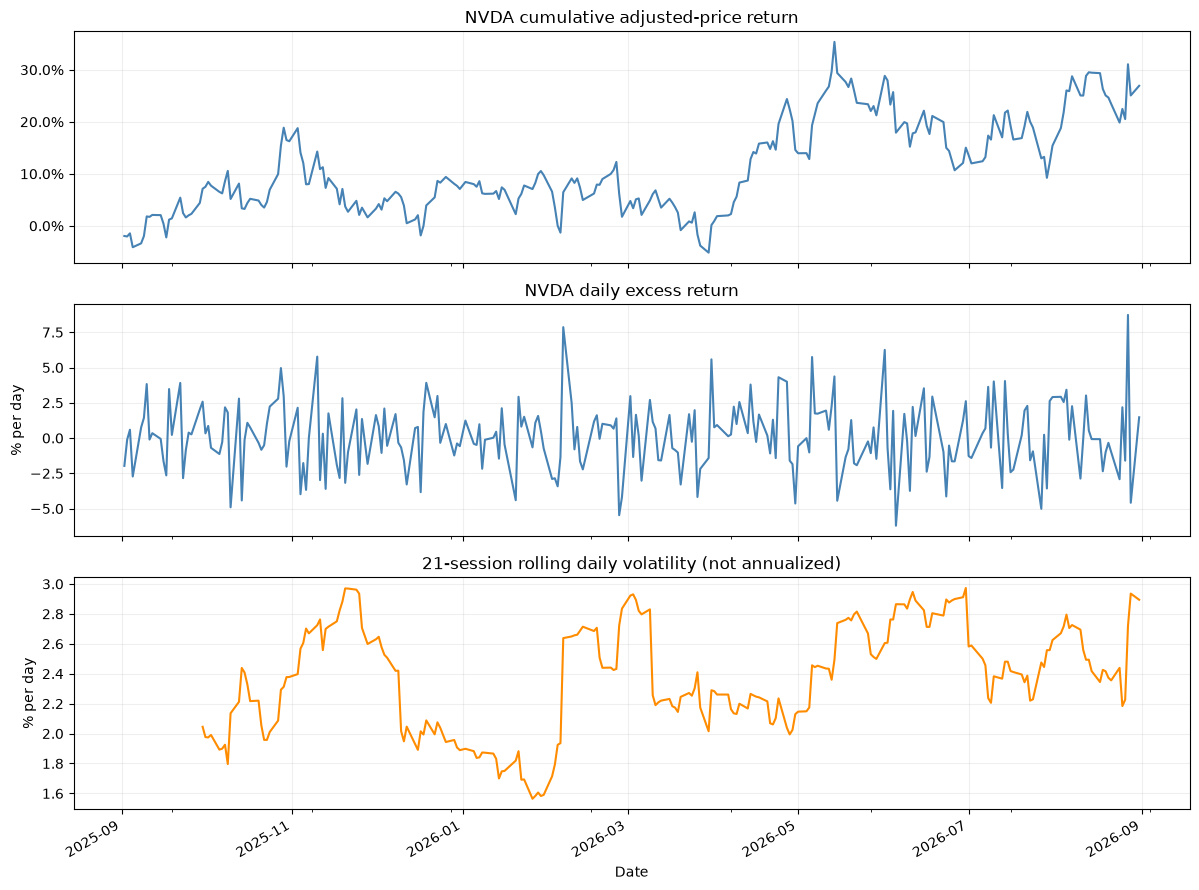

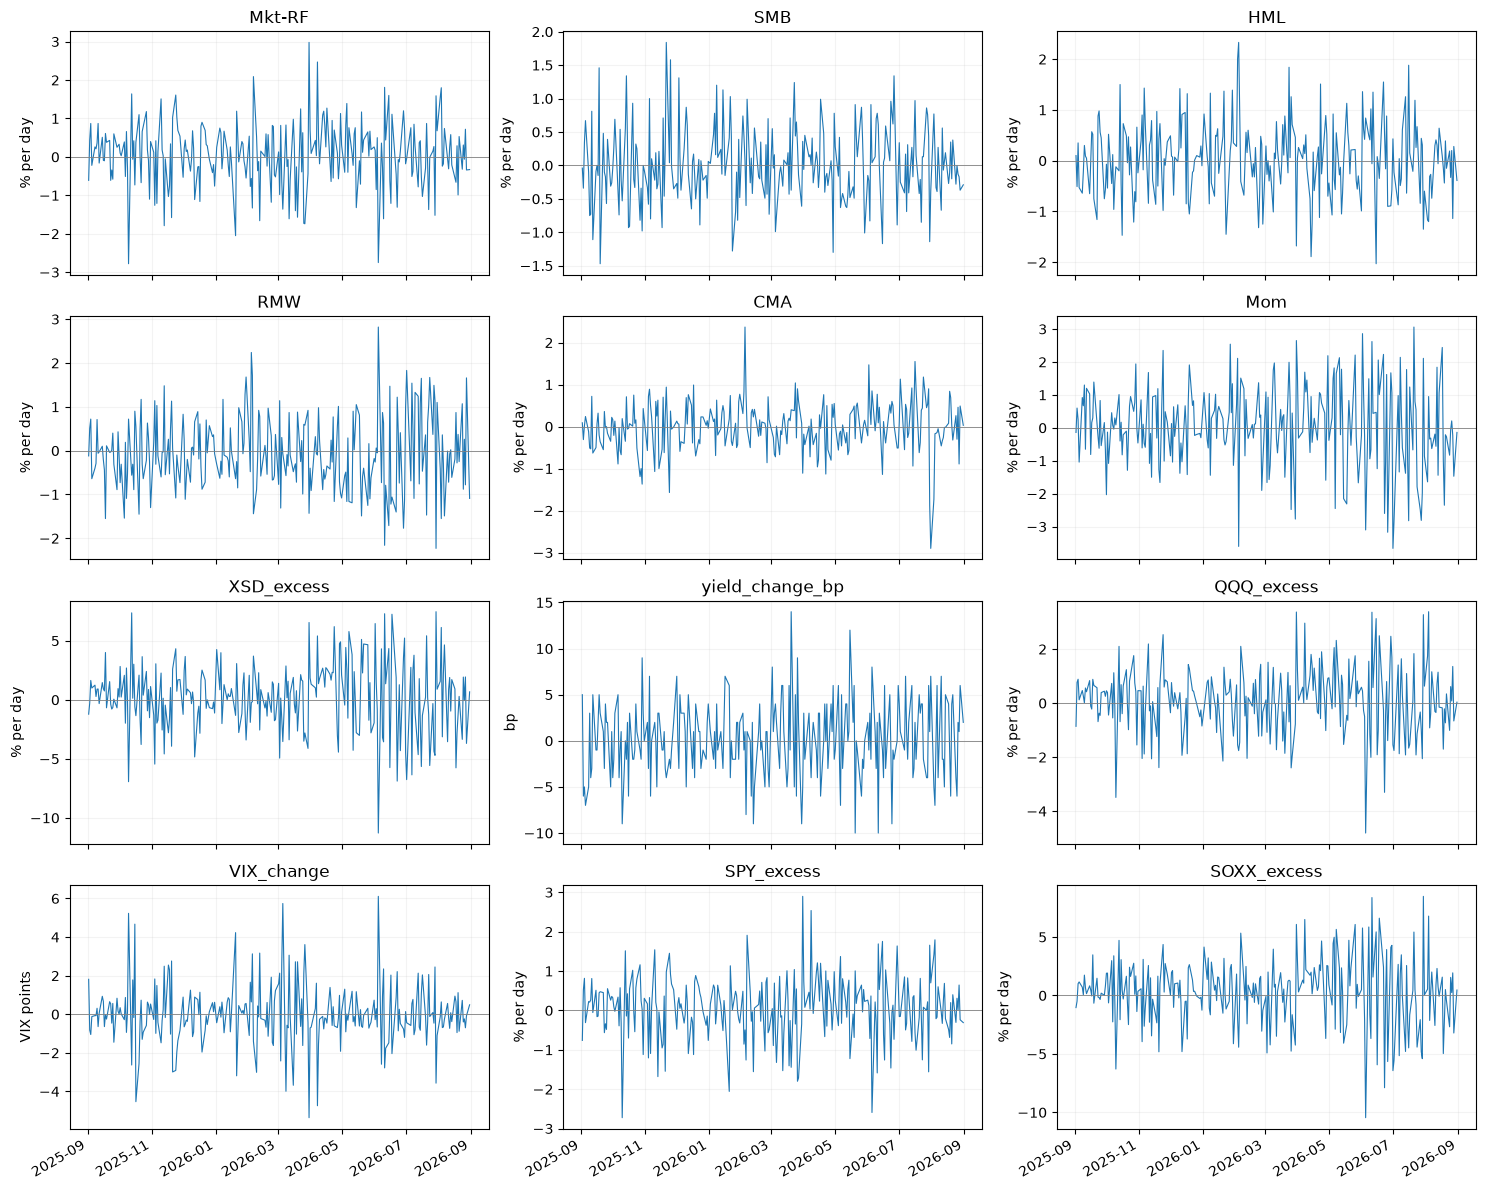

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
cumulative_return = (1 + data["NVDA_return"]).cumprod() - 1
axes[0].plot(data.index, cumulative_return, color="steelblue")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_title("NVDA cumulative adjusted-price return")
display_data["NVDA_excess"].plot(ax=axes[1], color="steelblue", title="NVDA daily excess return")
axes[1].set_ylabel("% per day")
(data["NVDA_excess"].rolling(21).std() * 100).plot(
    ax=axes[2], color="darkorange", title="21-session rolling daily volatility (not annualized)")
axes[2].set_ylabel("% per day")
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "nvda_performance.png", dpi=140)
plt.show()

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True)
for ax, column in zip(axes.flat, FACTOR_COLUMNS):
    ax.plot(display_data.index, display_data[column], linewidth=0.8)
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.set_title(column)
    ax.set_ylabel(units[column])
    ax.grid(alpha=0.15)
for ax in list(axes.flat)[len(FACTOR_COLUMNS):]:
    ax.set_visible(False)
fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_time_series.png", dpi=140)
plt.show()


## 8. Distributions and extreme observations

Histograms use each variable's own scale. Review tail dates against source prices and later event research; an extreme return is not automatically a data error. The table flags the ten largest absolute NVDA excess returns without modifying them.


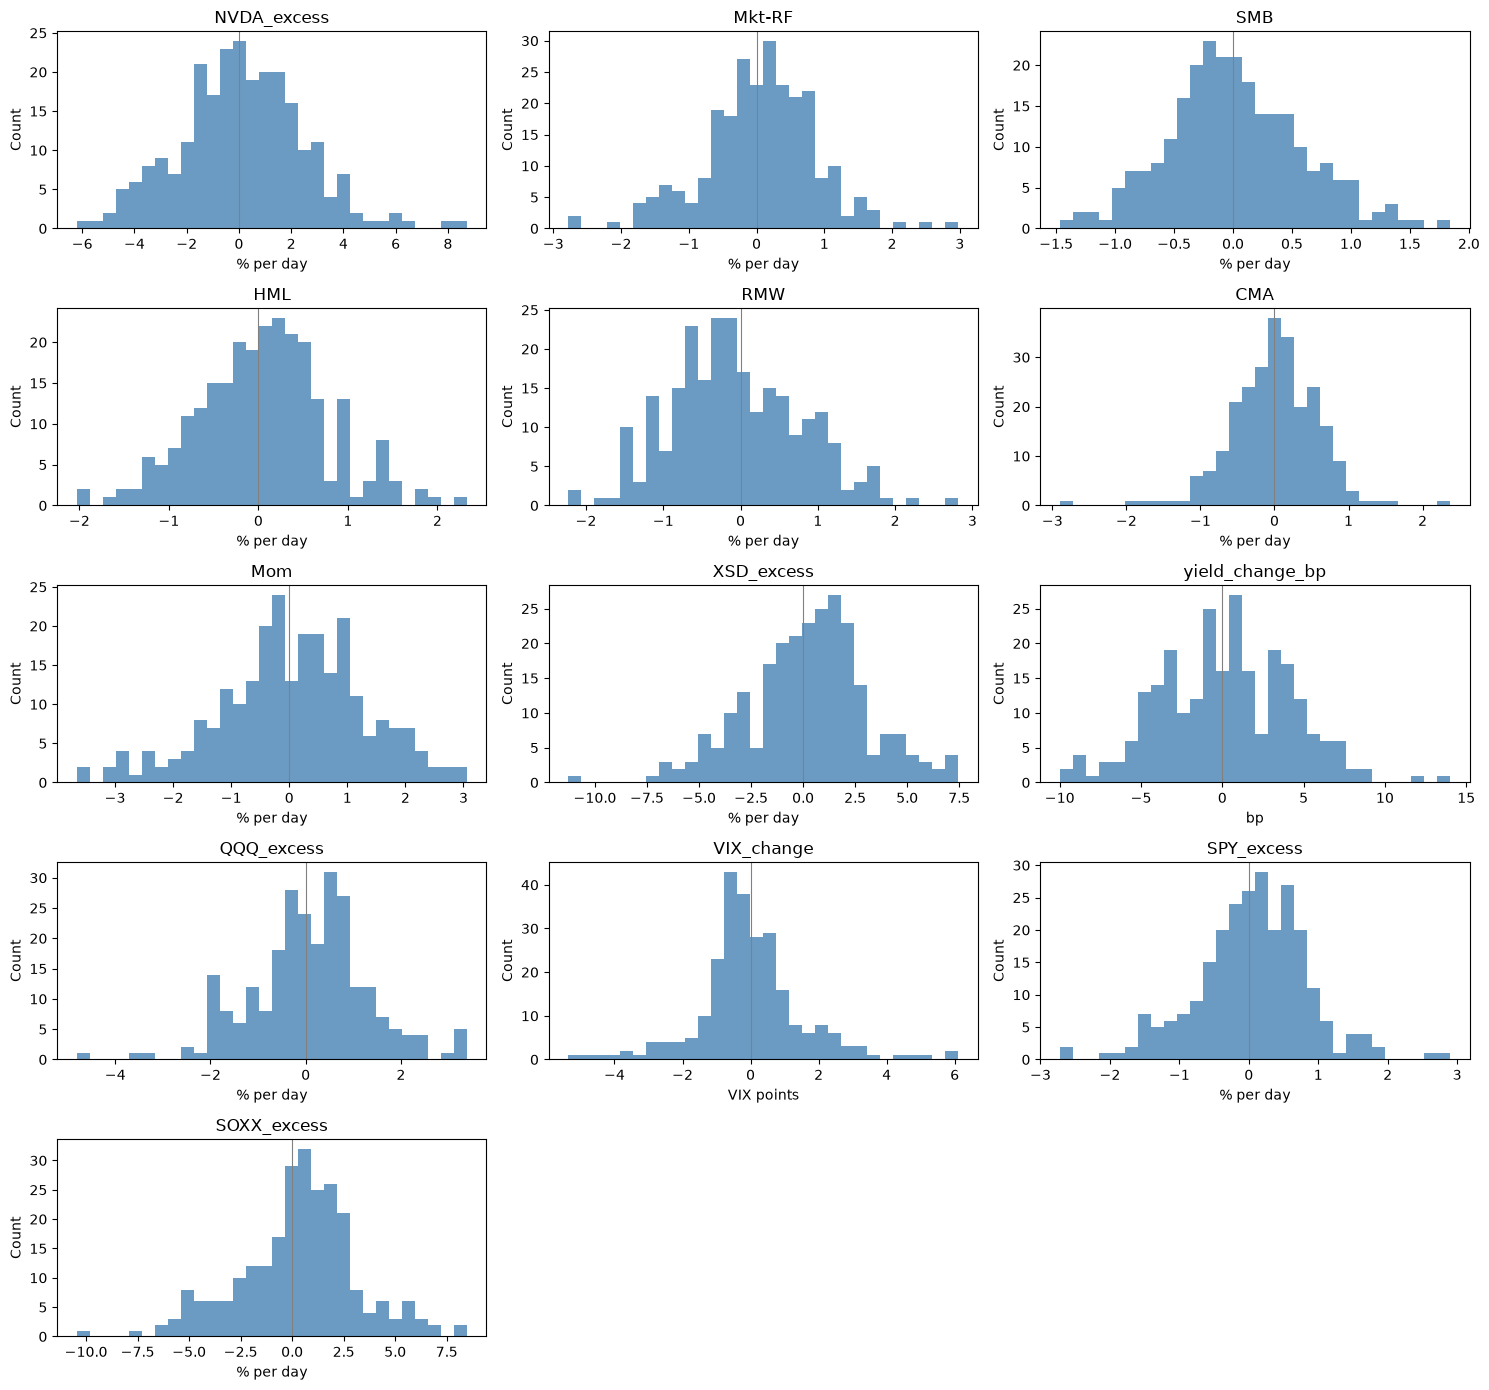

,NVDA_excess,Mkt-RF,SOXX_excess,QQQ_excess,yield_change_bp,VIX_change,NVDA_adjusted_price,previous_adjusted_price
Date,,,,,,,,
2026-08-27,8.7280,0.72,1.9360,1.3592,1.0,-0.70,227.7252,209.4257
2026-02-06,7.8618,2.09,5.3341,2.1038,1.0,-1.40,184.9771,171.4787
2026-06-01,6.2512,0.26,0.4908,0.5900,2.0,0.73,223.8483,210.6585
2026-06-05,-6.2114,-2.75,-10.4543,-4.8101,8.0,6.11,204.8708,218.4156
2025-11-10,5.7732,1.51,2.5685,2.1924,2.0,-1.48,198.5743,187.7003
2026-05-06,5.7459,1.39,4.9807,2.0574,-7.0,0.01,207.3560,196.0519
2026-03-31,5.5782,2.98,6.0812,3.3754,-5.0,-5.36,174.0023,164.7933
2026-02-26,-5.4661,-0.47,-3.0535,-1.2164,-3.0,0.70,184.4584,195.1035
2026-07-27,-5.0142,0.15,-2.0655,-0.3284,-4.0,0.09,196.2904,206.6088


In [11]:
fig, axes = plt.subplots(5, 3, figsize=(15, 14))
for ax, column in zip(axes.flat, EDA_COLUMNS):
    ax.hist(display_data[column], bins=30, color="steelblue", alpha=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_title(column)
    ax.set_xlabel(units[column])
    ax.set_ylabel("Count")
for ax in list(axes.flat)[len(EDA_COLUMNS):]:
    ax.set_visible(False)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "variable_distributions.png", dpi=140)
plt.show()

extreme_dates = data["NVDA_excess"].abs().nlargest(10).index
extremes = display_data.loc[extreme_dates, ["NVDA_excess", "Mkt-RF", "SOXX_excess", "QQQ_excess", "yield_change_bp", "VIX_change"]].copy()
extremes["NVDA_adjusted_price"] = adjusted_prices["NVDA"].reindex(extreme_dates)
extremes["previous_adjusted_price"] = adjusted_prices["NVDA"].shift(1).reindex(extreme_dates)
display(extremes.round(4))
extremes.to_csv(OUTPUT_DIR / "nvda_extreme_dates.csv")


## 9. Correlations and key relationships

Separate the target's pairwise correlations from correlations **between factors**. Pearson correlations describe linear co-movement; Spearman correlations provide a rank-based comparison. Neither establishes causality or incremental explanatory power. The ETF proxies can include NVDA, and their exposures overlap with market/style factors. Evaluate VIF separately for each model during the regression stage.


,Pearson,Spearman
QQQ_excess,0.675,0.656
SPY_excess,0.645,0.614
Mkt-RF,0.631,0.593
CMA,-0.610,-0.667
SOXX_excess,0.581,0.556
XSD_excess,0.495,0.485
VIX_change,-0.476,-0.448
Mom,0.472,0.493
HML,-0.465,-0.458
RMW,-0.368,-0.331


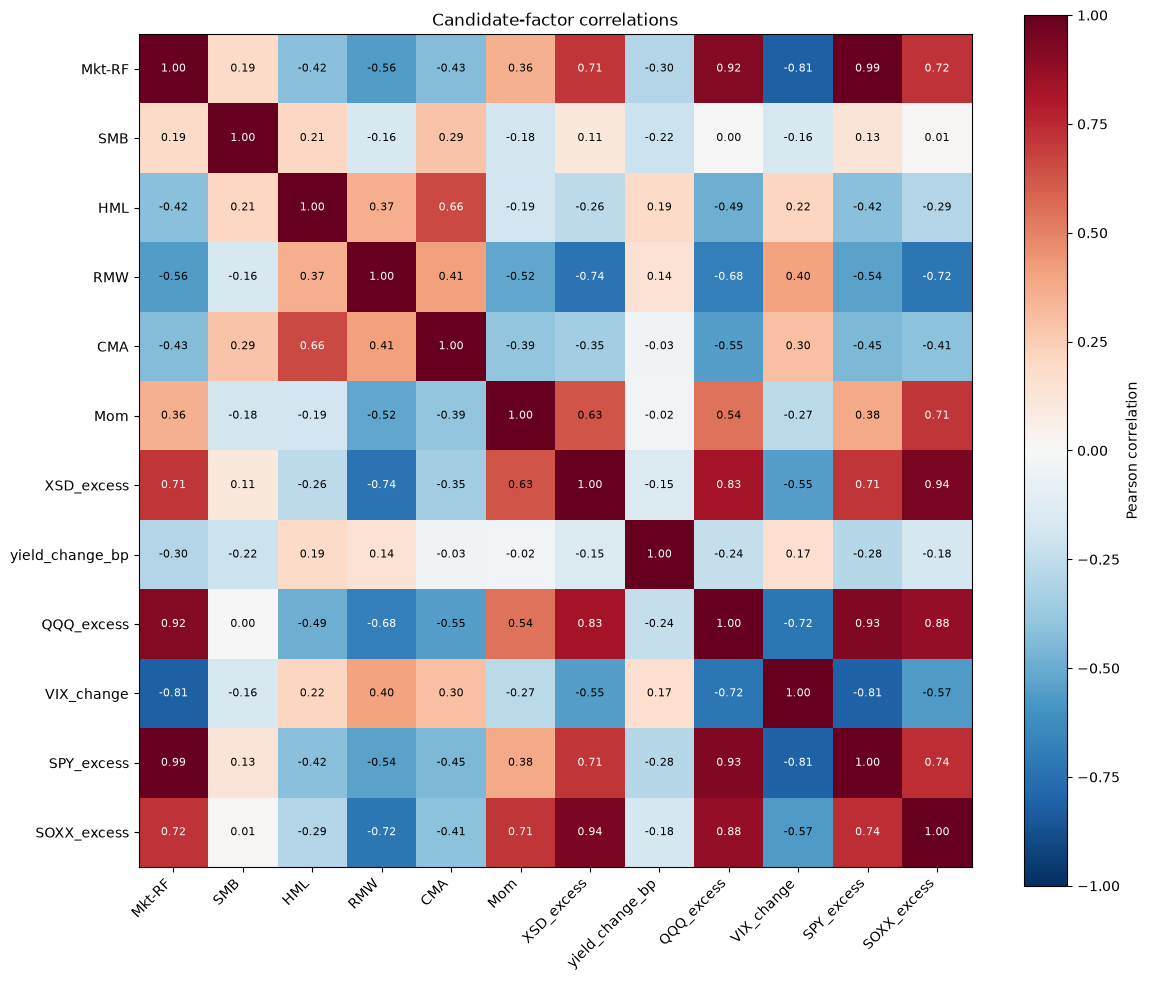

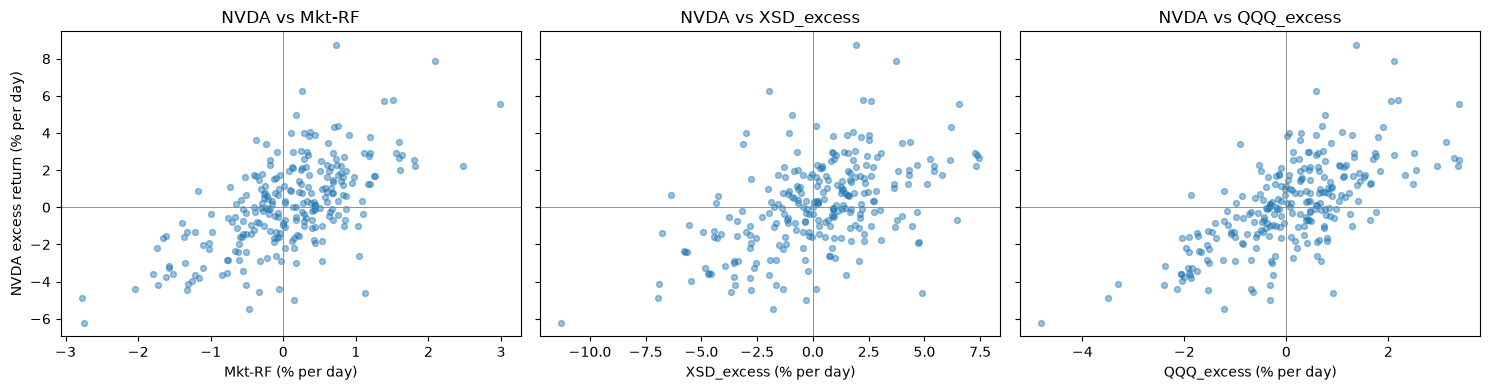

In [12]:
target_correlations = pd.DataFrame({
    "Pearson": variables[FACTOR_COLUMNS].corrwith(variables["NVDA_excess"]),
    "Spearman": variables[FACTOR_COLUMNS].corrwith(variables["NVDA_excess"], method="spearman"),
})
target_correlations = target_correlations.loc[target_correlations["Pearson"].abs().sort_values(ascending=False).index]
display(target_correlations.round(3))
factor_correlations = variables[FACTOR_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(factor_correlations, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FACTOR_COLUMNS)), FACTOR_COLUMNS, rotation=45, ha="right")
ax.set_yticks(range(len(FACTOR_COLUMNS)), FACTOR_COLUMNS)
for i in range(len(FACTOR_COLUMNS)):
    for j in range(len(FACTOR_COLUMNS)):
        value = factor_correlations.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.65 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Candidate-factor correlations")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_correlations.png", dpi=140)
plt.show()
target_correlations.to_csv(OUTPUT_DIR / "target_correlations.csv")
factor_correlations.to_csv(OUTPUT_DIR / "factor_correlations.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, column in zip(axes, ["Mkt-RF", "XSD_excess", "QQQ_excess"]):
    ax.scatter(display_data[column], display_data["NVDA_excess"], alpha=0.45, s=18)
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_xlabel(f"{column} (% per day)")
    ax.set_title(f"NVDA vs {column}")
axes[0].set_ylabel("NVDA excess return (% per day)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "key_scatterplots.png", dpi=140)
plt.show()


### Preliminary conclusions for regression design

- **Market:** Use Fama-French Mkt-RF. Keep SPY as an optional alternative market proxy, given their correlation of 0.993.
- **Industry:** Use XSD excess return as the primary semiconductor proxy; keep SOXX as an alternative rather than including both (correlation: 0.939).
- **QQQ:** Add QQQ in an extended model to assess its contribution beyond the market and industry factors.
- **Overlapping exposures:** XSD correlates with Mkt-RF (0.712), Momentum (0.631), and RMW (-0.735). Initially retain XSD and Momentum, then compare the full baseline with versions omitting each in turn, using model-specific VIF, coefficient stability, and incremental fit. These correlations alone do not show that semiconductor returns drive the Momentum factor. The baseline retains both for the primary comparison; Section 15 tests their separate incremental contributions before Section 16 states the model-selection conclusion.
- **Yield changes:** Add 10-year Treasury yield changes first to test their incremental contribution beyond the baseline factors.
- **VIX:** Add VIX changes in an extended model and assess their contribution after controlling for market movements.


## 10. AI-proposed exploratory investigation: stability and sensitivity

**Provenance:** This section was proposed and added by the AI assistant as an additional exploratory investigation. The window length, chronological half-sample split, and exclusion of ten extreme target days are analyst choices introduced by the assistant, not choices estimated from the data. These checks describe sensitivity and motivate possible follow-up analysis.

**Window notation and rationale:** A session means one observed equity trading day. Let W = 63 trading days, chosen as an approximate three-month window using 21 trading days per month × 3 months. This is a heuristic choice, not an exact calendar quarter or an optimized window. It balances responsiveness against sampling noise: shorter windows fluctuate more, while longer windows smooth over shorter-term changes.

**What each plotted point means:** For factor j at trading-day position t, plot the Pearson correlation between the 63 daily NVDA excess returns and the 63 same-date factor observations from positions t − 62 through t, inclusive. The first point is at position 63 and uses days 1–63; the next is at position 64 and uses days 2–64. The first 62 positions have no estimate because the code requires a full window. Each factor has its own correlation line. No cumulative return is calculated for this chart. Neighboring windows share 62 observations and their estimates are dependent.

Then compare two chronological sample halves, with observation counts shown; these are descriptive comparisons, not formal structural-break tests.

For sensitivity only, recompute target correlations after excluding the ten largest absolute NVDA excess returns. This target-based exclusion is not a recommended estimation sample: it shows how much the descriptive correlation depends on extreme target days. The full cleaned sample remains unchanged.


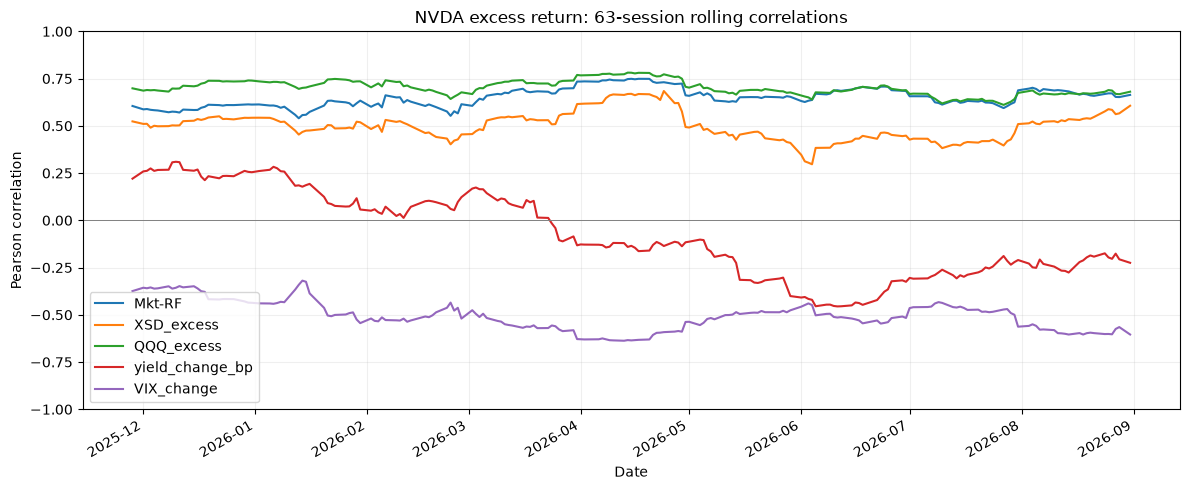

,Start,End,N,NVDA mean excess (% daily),NVDA volatility (% daily),Corr: Mkt-RF,Corr: XSD_excess,Corr: QQQ_excess,Corr: yield_change_bp,Corr: VIX_change
Period,,,,,,,,,,
First half,2025-09-02,2026-03-02,125,0.045,2.273,0.611,0.500,0.691,0.200,-0.421
Second half,2026-03-03,2026-08-31,126,0.170,2.522,0.646,0.507,0.672,-0.309,-0.519


,Full sample,Excluding 10 extreme target days,Difference
QQQ_excess,0.675,0.655,-0.020
SPY_excess,0.645,0.623,-0.022
Mkt-RF,0.631,0.607,-0.024
CMA,-0.610,-0.606,0.003
SOXX_excess,0.581,0.559,-0.022
XSD_excess,0.495,0.492,-0.003
VIX_change,-0.476,-0.474,0.003
Mom,0.472,0.437,-0.035
HML,-0.465,-0.444,0.021
RMW,-0.368,-0.331,0.037


Full sample: 251; sensitivity sample only: 241
Strongest absolute full-sample target correlation: QQQ_excess, r = 0.675
These are marginal relationships; incremental explanatory power requires model comparison.


In [13]:
key_factors = ["Mkt-RF", "XSD_excess", "QQQ_excess", "yield_change_bp", "VIX_change"]
# At day t, correlate paired observations from t-62 through t (63 trading days).
# The first estimate uses days 1-63; the next uses days 2-64.
# 63 approximates three trading months: 21 sessions/month * 3.
rolling_correlations = pd.DataFrame({
    column: variables["NVDA_excess"].rolling(63, min_periods=63).corr(variables[column])
    for column in key_factors
})
fig, ax = plt.subplots(figsize=(12, 5))
rolling_correlations.plot(ax=ax)
ax.axhline(0, color="gray", linewidth=0.7)
ax.set_ylim(-1, 1)
ax.set_ylabel("Pearson correlation")
ax.set_title("NVDA excess return: 63-session rolling correlations")
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "rolling_correlations.png", dpi=140)
plt.show()
rolling_correlations.to_csv(OUTPUT_DIR / "rolling_correlations.csv", index_label="Date")

midpoint = len(variables) // 2
stability_rows = []
for label, sample in [("First half", variables.iloc[:midpoint]),
                      ("Second half", variables.iloc[midpoint:])]:
    row = {"Period": label, "Start": sample.index.min().date(),
           "End": sample.index.max().date(), "N": len(sample),
           "NVDA mean excess (% daily)": sample["NVDA_excess"].mean() * 100,
           "NVDA volatility (% daily)": sample["NVDA_excess"].std() * 100}
    row.update({f"Corr: {c}": sample["NVDA_excess"].corr(sample[c]) for c in key_factors})
    stability_rows.append(row)
period_comparison = pd.DataFrame(stability_rows).set_index("Period")
display(period_comparison.round(3))
period_comparison.to_csv(OUTPUT_DIR / "period_comparison.csv")

sensitivity_sample = variables.drop(index=extreme_dates)
correlation_sensitivity = target_correlations[["Pearson"]].rename(columns={"Pearson": "Full sample"})
correlation_sensitivity["Excluding 10 extreme target days"] = (
    sensitivity_sample[FACTOR_COLUMNS].corrwith(sensitivity_sample["NVDA_excess"]))
correlation_sensitivity["Difference"] = (
    correlation_sensitivity["Excluding 10 extreme target days"] - correlation_sensitivity["Full sample"])
display(correlation_sensitivity.round(3))
print(f"Full sample: {len(variables)}; sensitivity sample only: {len(sensitivity_sample)}")
correlation_sensitivity.to_csv(OUTPUT_DIR / "correlation_sensitivity.csv")

strongest = target_correlations["Pearson"].abs().idxmax()
print(f"Strongest absolute full-sample target correlation: {strongest}, "
      f"r = {target_correlations.loc[strongest, 'Pearson']:.3f}")
print("These are marginal relationships; incremental explanatory power requires model comparison.")

## 11. Factor Model Specification and Estimation

This section defines the candidate models and how they are estimated. Model selection follows from the fit, incremental-factor tests and robustness checks in Sections 12–15; Section 16 states the preferred specification.

Compare four nested models of daily NVDA excess returns, estimated by OLS with an intercept on the same 251 trading observations (2025-09-02 to 2026-08-31):

| Model | Specification | Economic rationale |
| --- | --- | --- |
| M0: Baseline | Fama-French 5 + Momentum + XSD excess return | Capture broad market, style and semiconductor exposures |
| M1: + Yield | M0 + 10-year Treasury yield changes | Test incremental interest-rate exposure |
| M2: + QQQ | M1 + QQQ excess return | Test incremental technology/growth exposure |
| M3: + VIX | M2 + VIX changes | Test incremental volatility exposure |

**Baseline model (M0).**

$$
\begin{aligned}
r^{\mathrm{NVDA}}_t-r_{f,t}
= {} & \alpha + \beta_1\mathrm{MKT}_t + \beta_2\mathrm{SMB}_t
       + \beta_3\mathrm{HML}_t \\
     & + \beta_4\mathrm{RMW}_t + \beta_5\mathrm{CMA}_t
       + \beta_6\mathrm{MOM}_t \\
     & + \beta_7\left(r^{\mathrm{XSD}}_t-r_{f,t}\right) + \varepsilon_t.
\end{aligned}
$$

where:

| Symbol | Meaning |
| --- | --- |
| $t$ | Trading day |
| $r^{\mathrm{NVDA}}_t$ | NVDA daily return calculated from adjusted prices |
| $r_{f,t}$ | Daily risk-free return from the Kenneth French Data Library |
| $r^{\mathrm{NVDA}}_t-r_{f,t}$ | NVDA daily excess return, the dependent variable |
| $\alpha$ | Regression intercept: the component of mean daily excess return not captured by the included factors |
| $\mathrm{MKT}_t$ | Market excess-return factor (`Mkt-RF`): broad market return minus the risk-free return |
| $\mathrm{SMB}_t$ | Size factor, **Small Minus Big**: small-stock returns minus big-stock returns |
| $\mathrm{HML}_t$ | Value factor, **High Minus Low**: high book-to-market stock returns minus low book-to-market stock returns |
| $\mathrm{RMW}_t$ | Profitability factor, **Robust Minus Weak**: robust-profitability stock returns minus weak-profitability stock returns |
| $\mathrm{CMA}_t$ | Investment factor, **Conservative Minus Aggressive**: conservative-investment stock returns minus aggressive-investment stock returns |
| $\mathrm{MOM}_t$ | Momentum factor: past-winner stock returns minus past-loser stock returns |
| $r^{\mathrm{XSD}}_t-r_{f,t}$ | XSD ETF daily excess return, used as the semiconductor-industry proxy |
| $\beta_1,\ldots,\beta_7$ | NVDA's estimated exposures to market, size, value, profitability, investment, Momentum and XSD, respectively, conditional on the other included factors |
| $\varepsilon_t$ | Model error term: the part of daily NVDA excess return not captured by the included factors; its fitted counterpart is the residual $\hat{\varepsilon}_t$ |

**Extensions to M0.** M1 adds the 10-year Treasury yield change; M2 additionally adds QQQ daily excess return; M3 additionally adds the VIX change. Each model re-estimates the intercept and all included coefficients on the same sample. In the code and output tables, `Mkt-RF` corresponds to $\mathrm{MKT}_t$, `Mom` to $\mathrm{MOM}_t$, `XSD_excess` to $r^{\mathrm{XSD}}_t-r_{f,t}$, and `const` to $\alpha$.

**Units.** Returns and French factors enter in decimals. The French factors already represent excess or long-short returns; RF is subtracted only from the equity/ETF returns. Yield changes enter in basis points (bp; 1 bp = 0.01 percentage point) and VIX changes in index points. Since DGS10 is quoted in percent, `yield_change_bp` equals 100 times the change in the cleaned yield level; `VIX_change` is the change in the VIX level. Both changes follow the observed NVDA trading calendar. In the results tables, alpha is displayed in return bp/day, while yield and VIX slopes are displayed in return bp per yield bp and per VIX point, respectively.

**Standard errors and inference.** Daily return residuals may exhibit heteroskedasticity and short-term autocorrelation. Use Newey-West HAC standard errors with **5 trading-session lags** (approximately one trading week), and check sensitivity to 1 and 10 lags. Five lags is a practical, prespecified choice rather than an estimated optimal bandwidth. HAC adjusts standard errors, confidence intervals and significance tests; OLS coefficients and model fit stay the same.

The code uses Bartlett weights and a small-sample covariance correction, with asymptotic normal coefficient tests and chi-square Wald tests. See [Statsmodels robust covariance](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html).


In [14]:
# Local helpers make OLS/HAC estimation and incremental tests visible here.
HAC_LAGS = 5
MODEL_NAMES = list(MODEL_FACTORS)
MODEL_LABELS = dict(zip(MODEL_NAMES, ['M0: Baseline', 'M1: + Yield', 'M2: + QQQ', 'M3: + VIX']))

def fit_model(sample, factors, lag=HAC_LAGS):
    """Return OLS and corrected-covariance results without changing point estimates."""
    X = sm.add_constant(sample[factors], has_constant='add')
    if np.linalg.matrix_rank(X) != X.shape[1]:
        raise ValueError('Rank-deficient model matrix')
    ordinary = sm.OLS(sample['NVDA_excess'], X, missing='raise').fit()
    robust = ordinary.get_robustcov_results(
        cov_type='HAC', maxlags=lag, kernel='bartlett', use_correction=True, use_t=False)
    return ordinary, robust


OUTPUT_DIR = Path(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reg_sample = data[['NVDA_excess'] + MODEL_FACTORS['Plus VIX']].copy()

if reg_sample.empty or not np.isfinite(reg_sample.to_numpy()).all():
    raise ValueError("Empty or nonfinite model sample")

if not reg_sample.index.is_unique or not reg_sample.index.is_monotonic_increasing:
    raise ValueError("Model dates must be unique and increasing")

fits = {name: fit_model(reg_sample, cols) for name, cols in MODEL_FACTORS.items()}

coefficient_rows, fit_rows = [], []

for name, (ols, hac) in fits.items():
    for j, term in enumerate(ols.model.exog_names):
        ci = hac.conf_int()[j]
        coefficient_rows.append(dict(model=name, term=term, coefficient=hac.params[j],
            HAC_SE=hac.bse[j], HAC_t_stat=hac.tvalues[j], HAC_p_value=hac.pvalues[j],
            CI_low=ci[0], CI_high=ci[1]))
    fit_rows.append(dict(model=name, N=int(ols.nobs), parameters=len(ols.params),
        R2=ols.rsquared, adjusted_R2=ols.rsquared_adj,
        RMSE_bp=np.sqrt(np.mean(ols.resid**2))*10000,
        start=reg_sample.index.min().date(), end=reg_sample.index.max().date()))

coefficients = pd.DataFrame(coefficient_rows)

model_comparison = pd.DataFrame(fit_rows).set_index('model')

coefficients.to_csv(OUTPUT_DIR / 'regression_coefficients.csv', index=False)

model_comparison.to_csv(OUTPUT_DIR / 'regression_model_comparison.csv')

display(model_comparison.round(5))


,N,parameters,R2,adjusted_R2,RMSE_bp,start,end
model,,,,,,,
Baseline,251,8,0.58749,0.57561,153.64636,2025-09-02,2026-08-31
Plus rate,251,9,0.58792,0.57429,153.56666,2025-09-02,2026-08-31
Plus QQQ,251,10,0.58952,0.57419,153.26813,2025-09-02,2026-08-31
Plus VIX,251,11,0.59063,0.57357,153.06080,2025-09-02,2026-08-31


## 12. Regression summary table

Generate a table for the memo, with **one model per column**, to compare estimated factor exposures, statistical significance and model fit.

**How to read the coefficient rows**

- Each entry shows the estimated coefficient, followed by its **HAC standard error in parentheses**.
- Significance stars use two-sided HAC p-values: `***` for p < 0.01, `**` for p < 0.05, and `*` for p < 0.10. These p-values are not adjusted for multiple comparisons.
- The numeric export also provides coefficient/SE test statistics, p-values and 95% confidence intervals. The column `HAC_t_stat` retains the export name, but it is interpreted as a **z-statistic** because estimation uses asymptotic normal inference (`use_t=False`).

**Units**

| Row | Interpretation |
| --- | --- |
| Return factors | Change in NVDA excess return per unit change in factor return |
| Alpha | Basis points of NVDA excess return per day |
| Yield change | Basis points of NVDA excess return per +1 bp change in the 10-year yield |
| VIX change | Basis points of NVDA excess return per +1 VIX index point |

Returns are estimated in decimal units; alpha, yield and VIX coefficients are rescaled for display.

**Model fit**

The bottom rows report observations, R-squared, adjusted R-squared and daily RMSE in basis points. These describe fit within the estimation sample. Incremental factor tests and detailed diagnostics follow in Sections 13-15.


In [15]:
OUTPUT_DIR = Path(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

terms = ['const'] + MODEL_FACTORS['Plus VIX']

labels = {'const': 'Alpha (bp/day)', 'Mkt-RF': 'Market excess', 'Mom': 'Momentum',
          'XSD_excess': 'XSD excess', 'QQQ_excess': 'QQQ excess',
          'yield_change_bp': 'Yield change (return bp / yield bp)',
          'VIX_change': 'VIX change (return bp / point)'}

def display_scale(term):
    return 10000 if term in ['const', 'yield_change_bp', 'VIX_change'] else 1

def stars(p):
    return '***' if p < .01 else '**' if p < .05 else '*' if p < .10 else ''

regression_table = pd.DataFrame(index=[labels.get(t, t) for t in terms])

for name in MODEL_NAMES:
    rows = coefficients[coefficients.model == name].set_index('term')
    regression_table[MODEL_LABELS[name]] = [
        f"{rows.loc[t, 'coefficient']*display_scale(t):.3f}{stars(rows.loc[t, 'HAC_p_value'])} "
        f"({rows.loc[t, 'HAC_SE']*display_scale(t):.3f})" if t in rows.index else '—'
        for t in terms]

for label, key, fmt in [('Observations', 'N', '.0f'), ('R-squared', 'R2', '.4f'),
                         ('Adjusted R-squared', 'adjusted_R2', '.4f'),
                         ('RMSE (bp/day)', 'RMSE_bp', '.2f')]:
    regression_table.loc[label] = [format(model_comparison.loc[n, key], fmt) for n in MODEL_NAMES]

regression_table.to_csv(OUTPUT_DIR / 'regression_summary_table.csv', index_label='Term')

table_notes = (f"Sample: {reg_sample.index.min():%Y-%m-%d} to {reg_sample.index.max():%Y-%m-%d}; "
    "daily NVDA excess return. OLS with intercept. Parentheses: HAC SE, Bartlett, 5 lags, "
    "small-sample correction; asymptotic normal inference. *** p<.01, ** p<.05, * p<.10. "
    "Return-factor slopes are unitless; alpha in bp/day; yield and VIX slopes in return bp "
    "per yield bp and index point, respectively. RMSE is in-sample. No causal or forecast claim.")

table_html = '<h2>NVDA daily excess return: nested factor regressions</h2>' + regression_table.to_html() + '<p>' + table_notes + '</p>'

display(HTML(table_html))

html_doc = ('<!doctype html><html><head><meta charset="utf-8"><style>'
    'body{font-family:Georgia,serif;max-width:1150px;margin:40px auto;color:#17212b}'
    'table{border-collapse:collapse;width:100%;font-size:15px}th,td{padding:10px;text-align:right;white-space:nowrap}'
    'th:first-child{text-align:left}thead{border-top:2px solid;border-bottom:1px solid}'
    'tbody{border-bottom:2px solid}p{font-size:13px;line-height:1.5}'
    '</style></head><body>' + table_html + '</body></html>')

(OUTPUT_DIR / 'regression_summary_table.html').write_text(html_doc, encoding='utf-8')


,M0: Baseline,M1: + Yield,M2: + QQQ,M3: + VIX
Alpha (bp/day),3.609 (8.201),3.303 (8.218),3.319 (8.263),2.254 (8.405)
Market excess,1.422*** (0.205),1.444*** (0.216),1.113*** (0.426),1.281*** (0.478)
SMB,-0.268 (0.241),-0.253 (0.249),-0.150 (0.269),-0.160 (0.266)
HML,-0.156 (0.227),-0.181 (0.236),-0.167 (0.238),-0.134 (0.241)
RMW,0.480** (0.194),0.480** (0.195),0.524*** (0.199),0.526*** (0.200)
CMA,-1.297*** (0.346),-1.266*** (0.357),-1.207*** (0.325),-1.209*** (0.324)
Momentum,0.448*** (0.124),0.452*** (0.127),0.440*** (0.130),0.440*** (0.131)
XSD excess,0.001 (0.071),-0.002 (0.072),-0.042 (0.088),-0.045 (0.090)
Yield change (return bp / yield bp),—,1.353 (2.540),1.643 (2.506),1.862 (2.580)
QQQ excess,—,—,0.349 (0.376),0.346 (0.376)


3443

In [16]:
# Save the Section 12 table for the memo without displaying it again.
from _LIB_case1 import export_summary_figure
export_summary_figure(regression_table, table_notes, OUTPUT_DIR, show_figures=False)
print("Saved regression_summary_table.png for the memo.")


Saved regression_summary_table.png for the memo.


## 13. Incremental contribution

Does adding a factor improve the model enough to justify including it? Compare each model with the preceding model on the **same observations**: M1 adds yield changes to M0, M2 adds QQQ to M1, and M3 adds VIX changes to M2.

**How much additional variation does the factor explain?**

The change in R-squared measures the increase in the proportion of **total** NVDA excess-return variation explained:

$$
\Delta R^2 = R^2_{\text{expanded}} - R^2_{\text{previous}}.
$$

Partial R-squared measures the proportion of the previous model's **remaining unexplained variation** explained by the added factor:

$$
R^2_{\text{partial}}
= \frac{SSR_{\text{previous}} - SSR_{\text{expanded}}}{SSR_{\text{previous}}}
= \frac{R^2_{\text{expanded}} - R^2_{\text{previous}}}{1 - R^2_{\text{previous}}}.
$$

Here, $y_t=r^{\mathrm{NVDA}}_t-r_{f,t}$ is daily NVDA excess return, $\hat{y}_t$ is its fitted value, and $SSR = \sum_t (y_t - \hat{y}_t)^2$ is the sum of squared residuals. For example, increasing R-squared from 60% to 62% gives a partial R-squared of $(0.62 - 0.60)/(1 - 0.60) = 5\%$: the added factor explains 5% of what the previous model left unexplained.

**Is the additional contribution statistically significant?**

The HAC Wald test checks whether the added factor's coefficient is zero, using HAC-corrected uncertainty. The `HAC_p_value` column reports its p-value; we use 0.05 as the reference significance level. A small p-value supports a nonzero conditional coefficient. Partial R-squared measures the size of the fit improvement; the Wald test assesses statistical significance.

The table first compares models in their order of addition, then tests all three extensions jointly against the baseline. Its final three rows remove each extension individually from the full model, measuring its contribution after controlling for the other extensions. R-squared and partial R-squared are reported as decimals; multiply by 100 to express them as percentages. Multiply `delta_R2` by 100 to express the change in **percentage points**. Sequential R-squared increments sum to the total increase from M0 to M3, but depend on the order in which factors enter. The conditional increments and partial R-squared values are not additive and do not provide a unique factor attribution.


In [17]:
def nested_row(label, restricted, unrestricted, robust, excluded):
    """Report incremental fit and a HAC chi-square test of specified zero slopes."""
    names = unrestricted.model.exog_names
    R = np.zeros((len(excluded), len(names)))
    for i, term in enumerate(excluded):
        R[i, names.index(term)] = 1
    w = robust.wald_test(R, use_f=False, scalar=True)
    return dict(comparison=label, delta_R2=unrestricted.rsquared-restricted.rsquared,
        partial_R2=(restricted.ssr-unrestricted.ssr)/restricted.ssr,
        HAC_Wald=float(w.statistic), df=len(excluded), HAC_p_value=float(w.pvalue))


OUTPUT_DIR = Path(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

increment_rows = []

for prior, current in zip(MODEL_NAMES[:-1], MODEL_NAMES[1:]):
    added = [c for c in MODEL_FACTORS[current] if c not in MODEL_FACTORS[prior]]
    increment_rows.append(nested_row(f'{MODEL_LABELS[current]} vs {MODEL_LABELS[prior]}', fits[prior][0], *fits[current], added))

extensions = ['yield_change_bp', 'QQQ_excess', 'VIX_change']

increment_rows.append(nested_row('M3 vs M0: all extensions', fits['Baseline'][0], *fits['Plus VIX'], extensions))

for term in extensions:
    restricted, _ = fit_model(reg_sample, [c for c in MODEL_FACTORS['Plus VIX'] if c != term])
    increment_rows.append(nested_row(f'M3 conditional: {term}', restricted, *fits['Plus VIX'], [term]))

incremental_fit = pd.DataFrame(increment_rows).set_index('comparison')

display(incremental_fit.round(5))

incremental_fit.to_csv(OUTPUT_DIR / 'regression_incremental_fit.csv')


,delta_R2,partial_R2,HAC_Wald,df,HAC_p_value
comparison,,,,,
M1: + Yield vs M0: Baseline,0.00043,0.00104,0.28383,1,0.59420
M2: + QQQ vs M1: + Yield,0.00160,0.00388,0.85943,1,0.35390
M3: + VIX vs M2: + QQQ,0.00111,0.00270,0.78553,1,0.37546
M3 vs M0: all extensions,0.00314,0.00761,1.68778,3,0.63966
M3 conditional: yield_change_bp,0.00079,0.00193,0.52129,1,0.47029
M3 conditional: QQQ_excess,0.00158,0.00384,0.84608,1,0.35766
M3 conditional: VIX_change,0.00111,0.00270,0.78553,1,0.37546


**Conclusion.** Models M1, M2 and M3 provide only small incremental improvements, and none of the added factors is statistically significant at the 5% level when introduced (HAC p-values: 0.594, 0.354 and 0.375); the three extensions are also jointly insignificant (p = 0.640). Together with the lower adjusted R-squared of the expanded models, these results favor retaining model M0, the baseline, among the four primary specifications.


## 14. Model-specific diagnostics and coefficient stability

### 14.1 Multicollinearity: calculate VIF

The correlation matrix in Section 9 checks pairwise relationships. **Variance inflation factor (VIF)** checks how well each factor is explained by all the other factors in the same model. Both diagnose overlapping information; neither corrects multicollinearity.

The code below calculates and displays a VIF table for M0-M3. Auxiliary regressions include an intercept, but its VIF is not reported. Values above 5 or 10 are warning flags, not automatic deletion rules.

In [18]:
vif_rows = []
for name, (ols, hac) in fits.items():
    X = pd.DataFrame(ols.model.exog, columns=ols.model.exog_names, index=reg_sample.index)
    for j, term in enumerate(X.columns):
        if term != 'const':
            vif_rows.append(dict(model=name, term=term,
                                 VIF=variance_inflation_factor(X.to_numpy(), j)))
vif_table = pd.DataFrame(vif_rows).pivot(index='term', columns='model', values='VIF').reindex(columns=MODEL_NAMES)
display(vif_table.rename(columns=MODEL_LABELS).round(2))
vif_table.to_csv(OUTPUT_DIR / 'regression_vif.csv')


model,M0: Baseline,M1: + Yield,M2: + QQQ,M3: + VIX
term,,,,
CMA,2.26,2.40,2.53,2.53
HML,2.02,2.15,2.16,2.25
Mkt-RF,2.65,2.79,10.99,14.03
Mom,2.04,2.05,2.08,2.08
QQQ_excess,NaN,NaN,20.11,20.11
RMW,2.57,2.57,2.72,2.72
SMB,1.46,1.49,1.86,1.86
VIX_change,NaN,NaN,NaN,3.22
XSD_excess,4.06,4.08,5.56,5.57


**Interpretation and factor selection**

QQQ's VIF is about 20 in M2/M3; market VIF rises from 2.65 in M0 to 14.03 in M3. This indicates that their independent coefficients are harder to estimate precisely.

Combine VIF with economic rationale, incremental fit and coefficient stability before removing a variable. Removing an essential control can introduce omitted-variable bias, even if its VIF is high. Refit and reassess diagnostics after any change.

| Factor | Evidence from Sections 12-15 | Implication |
| --- | --- | --- |
| QQQ | VIF about 20; small incremental fit; insignificant HAC coefficient; market SE increases | Evidence supports omission from the preferred primary model |
| XSD | M0 VIF about 4; coefficient near zero; its omission in Section 15 barely changes R-squared | Consider omission for limited incremental contribution, while weighing its industry-control rationale |
| Momentum | VIF about 2; significant coefficient; its omission in Section 15 reduces fit | Evidence supports retention |

These are sample-specific judgments. The four prespecified primary models remain the main comparison; omissions are labeled sensitivity checks in Section 15.

### 14.2 Coefficient stability across models

The next figure shows market, Momentum and XSD coefficients with **95% HAC confidence intervals** across M0-M3. Look for changes in coefficient estimates and widening intervals as factors are added. Stability over time is examined separately in Section 15.

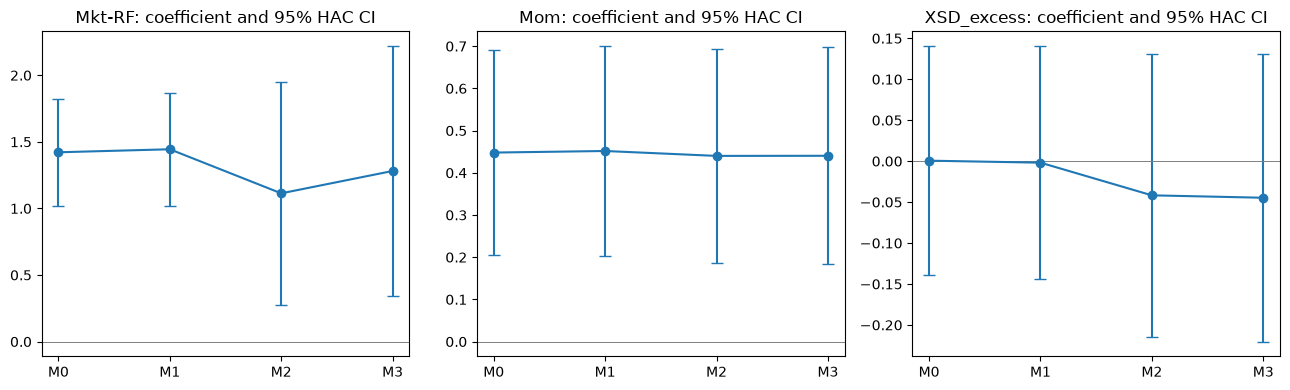

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, term in zip(axes, ['Mkt-RF', 'Mom', 'XSD_excess']):
    rows = coefficients[coefficients.term == term].set_index('model').loc[MODEL_NAMES]
    ax.errorbar(range(4), rows.coefficient, yerr=1.96*rows.HAC_SE, fmt='o-', capsize=4)
    ax.set_xticks(range(4), ['M0', 'M1', 'M2', 'M3']); ax.axhline(0, color='gray', lw=.7)
    ax.set_title(term + ': coefficient and 95% HAC CI')

fig.tight_layout(); fig.savefig(OUTPUT_DIR / 'regression_coefficient_stability.png', dpi=160)

plt.show()


**Interpretation.** The market HAC standard error rises from 0.205 in M0 to 0.478 in M3, consistent with the added overlapping exposures. Momentum remains around 0.44-0.45, while XSD's interval includes zero in every primary model.

### 14.3 Other diagnostics: residual dependence and variance

*AI-suggested further analysis.*

A **residual** is actual NVDA excess return minus the model's fitted return. The table below checks properties of what the model leaves unexplained.

| Output column | Full name / purpose | Null hypothesis |
| --- | --- | --- |
| `LB_p_lag5` | Ljung-Box (LB) test, jointly examining residual autocorrelation at lags 1-5 trading sessions | Those autocorrelations are all zero |
| `LB_p_lag10` | Ljung-Box test, jointly examining lags 1-10 | Those autocorrelations are all zero |
| `Koenker_BP_p` | Koenker version of the Breusch-Pagan test (KBP), checking whether residual variance depends on the included factors | Residual variance is constant |

**Reading a p-value.** Under the null hypothesis and the test's assumptions, it is the probability of a test statistic at least as extreme as the one observed. A p-value below 0.05 provides evidence against that null at the 5% level; a value of 0.05 or higher means insufficient evidence to reject it, not proof that the null is true. These p-values test residual properties, not whether a factor coefficient is significant.

The Koenker version relaxes the original Breusch-Pagan test's normality requirement; it is **not** a HAC correction of the diagnostic test. Treat these tests as exploratory checks, especially when residual dependence is present, and retain the prespecified HAC coefficient inference.

References: [Ljung-Box documentation](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html) and [Koenker/Breusch-Pagan documentation](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.het_breuschpagan.html).

In [20]:
diagnostic_rows = []
for name, (ols, hac) in fits.items():
    X = pd.DataFrame(ols.model.exog, columns=ols.model.exog_names, index=reg_sample.index)
    lb = acorr_ljungbox(ols.resid, lags=[5, 10], return_df=True)
    bp = het_breuschpagan(ols.resid, X, robust=True)  # Koenker version; bp[1] is LM p-value.
    influence = ols.get_influence()
    diagnostic_rows.append(dict(model=name,
        LB_p_lag5=lb.loc[5, 'lb_pvalue'], LB_p_lag10=lb.loc[10, 'lb_pvalue'],
        Koenker_BP_p=bp[1], max_Cook_D=influence.cooks_distance[0].max()))
diagnostics = pd.DataFrame(diagnostic_rows).set_index('model')
display(diagnostics.drop(columns='max_Cook_D').rename(index=MODEL_LABELS).round(5))
diagnostics.to_csv(OUTPUT_DIR / 'regression_diagnostics.csv')


,LB_p_lag5,LB_p_lag10,Koenker_BP_p
model,,,
M0: Baseline,0.02715,0.16167,0.10382
M1: + Yield,0.02254,0.14586,0.04774
M2: + QQQ,0.02088,0.13110,0.06286
M3: + VIX,0.01774,0.11854,0.07106


**Interpretation.** Lag-5 Ljung-Box p-values are about 0.018-0.027, suggesting short-term residual autocorrelation; lag-10 p-values are above 0.05, so the conclusion depends on the tested horizon. Koenker/Breusch-Pagan p-values are about 0.048-0.104, giving only mixed evidence of variance changes across models. HAC accommodates these concerns in coefficient inference but does not remove residual dependence or variance changes.

The next plots show residuals over time and their **autocorrelation function (ACF)**: residual correlation with its own lagged values. They are displayed for M0 and M3.

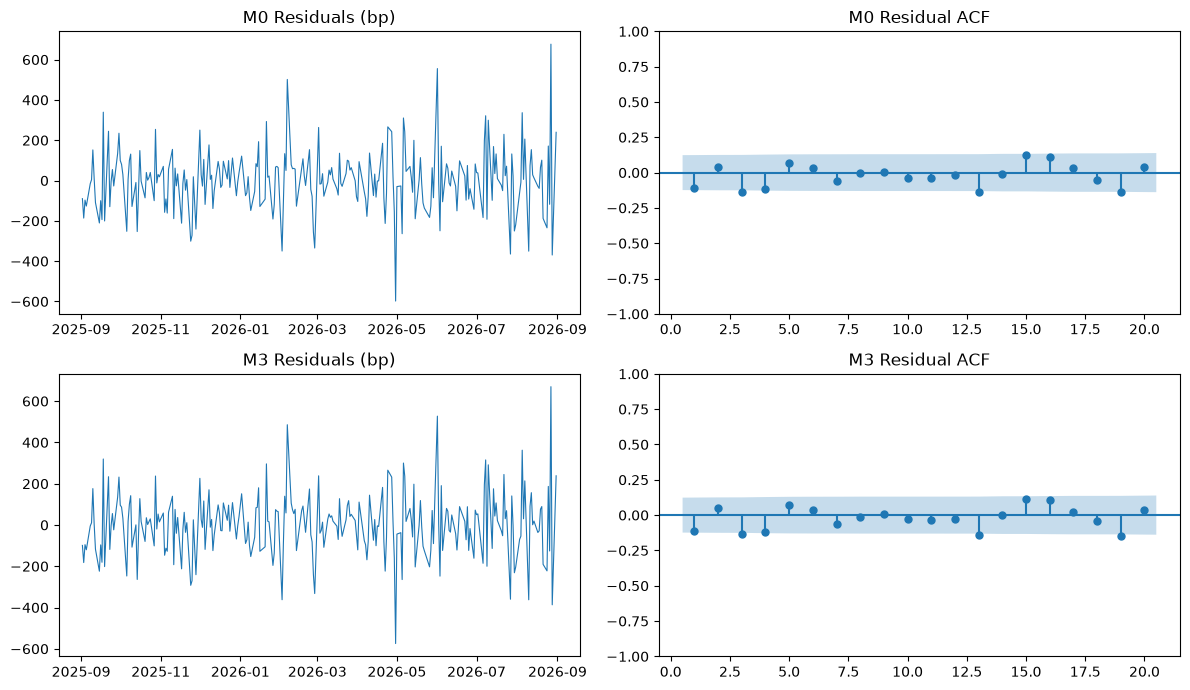

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

from statsmodels.graphics.tsaplots import plot_acf

for row, name in enumerate(['Baseline', 'Plus VIX']):
    model_id = 'M0' if name == 'Baseline' else 'M3'
    axes[row, 0].plot(reg_sample.index, fits[name][0].resid*10000, lw=.8)
    axes[row, 0].set_title(model_id + ' Residuals (bp)')
    plot_acf(fits[name][0].resid, lags=20, ax=axes[row, 1], zero=False, title=model_id + ' Residual ACF')

fig.tight_layout(); fig.savefig(OUTPUT_DIR / 'regression_residuals.png', dpi=160)

plt.show()


### 14.4 Influential observations

*AI-suggested further analysis.*

**Purpose: check whether a few trading days strongly influence our regression results.**

For each model, calculate the following three measures for **every trading day**:

| Measure | Plain-language meaning |
| --- | --- |
| Cook's distance | How much would the fitted model change if we left this day out? Larger values indicate greater influence on the estimated coefficients. |
| Leverage | How unusual is this day's combination of factor values compared with the rest of the sample? |
| Externally studentized residual | NVDA's actual excess return minus its fitted excess return, divided by an estimated residual standard deviation that accounts for leverage and uses an error-variance estimate excluding that day. Positive means above the fitted value; negative means below. |

The code ranks days by Cook's distance and displays the **five largest values for each model**. Five is a convenient reporting choice, not a statistical cutoff; displaying three would simply show fewer dates. All days are included in the calculations and in the primary regression. The dates in the table are taken from the original sample index after ranking.

Use the table to identify dates for data checks and follow-up sensitivity analysis. A large Cook's distance does not by itself mean the observation is wrong or should be deleted.


In [22]:
influence_rows = []
for name, (ols, hac) in fits.items():
    influence = ols.get_influence()
    for i in np.argsort(influence.cooks_distance[0])[-5:][::-1]:
        influence_rows.append(dict(model=name, date=reg_sample.index[i],
            Cook_D=influence.cooks_distance[0][i], leverage=influence.hat_matrix_diag[i],
            studentized_residual=influence.resid_studentized_external[i]))
influence_table = pd.DataFrame(influence_rows)
display(influence_table.assign(model=influence_table.model.map(MODEL_LABELS)))
influence_table.to_csv(OUTPUT_DIR / 'regression_influence.csv', index=False)


,model,date,Cook_D,leverage,studentized_residual
0,M0: Baseline,2026-04-30,0.125321,0.060376,-4.074912
1,M0: Baseline,2026-07-31,0.091604,0.223583,-1.600370
2,M0: Baseline,2026-02-06,0.073108,0.051033,3.367273
3,M0: Baseline,2026-08-27,0.050459,0.020620,4.553055
4,M0: Baseline,2026-07-27,0.039311,0.051829,-2.422515
5,M1: + Yield,2026-04-30,0.117196,0.062628,-4.101076
6,M1: + Yield,2026-07-31,0.083047,0.224238,-1.613346
7,M1: + Yield,2026-02-06,0.076408,0.060819,3.325755
8,M1: + Yield,2026-08-27,0.045735,0.021182,4.534053
9,M1: + Yield,2026-06-01,0.039170,0.026921,3.659946


**Illustration: three dates worth reviewing**

These dates illustrate different combinations of residual size and leverage; they are not the three highest-ranked observations. The full table above identifies the five most influential dates in each model.

- **April 30, 2026:** The most influential day in all four models, with Cook's distance around 0.12-0.14. In M0, the studentized residual is -4.07: NVDA's excess return was far below its fitted value.
- **July 31, 2026:** Influential because the factor values were unusual. In M0, leverage is 0.224 and Cook's distance is 0.092, even though the studentized residual (-1.60) is less extreme than on the other two dates.
- **August 27, 2026:** A large positive excess-return residual, but less influence on the coefficients than the preceding two examples. In M0, the studentized residual is +4.55, while leverage is 0.021 and Cook's distance is 0.050. A larger residual does not necessarily mean greater influence.

Retain these dates in the primary sample, check their underlying data and assess coefficient/model-selection sensitivity by leaving each date out in turn. This table identifies potentially influential observations; it does not yet establish whether excluding them changes our conclusions.


## 15. Robustness and sensitivity checks

**Purpose: check whether our main conclusions change when we make a different reasonable modeling choice.** The primary results are M0-M3 in Section 12. The checks below are alternative estimates, not replacements for those results.

We ask five specific questions, one at a time:

| Check | Question |
| --- | --- |
| 15.1 Factor omission | Do Momentum and XSD add useful information to M0? |
| 15.2 Industry proxy | Does choosing SOXX instead of XSD change the results? |
| 15.3 HAC lag choice | Does significance depend on using 5 lags rather than 1 or 10? |
| 15.4 Yield-gap treatment | Do the few filled yield observations drive the results? |
| 15.5 Time stability | Are estimated exposures similar across different parts of the year? |

Each subsection states what changes, displays the relevant results and gives a short interpretation. This section does not yet exclude the influential dates identified in Section 14.4.

In [23]:
# Collect alternative fits; small local helpers keep each check readable.
sensitivity_rows, sensitivity_coefs = [], []
def record_sensitivity(label, sample, factors, lag=HAC_LAGS):
    ols, hac = fit_model(sample, factors, lag)
    sensitivity_rows.append(dict(specification=label, N=len(sample), R2=ols.rsquared,
        adjusted_R2=ols.rsquared_adj, RMSE_bp=np.sqrt(np.mean(ols.resid**2))*10000))
    for i, term in enumerate(ols.model.exog_names):
        sensitivity_coefs.append(dict(specification=label, term=term, coefficient=hac.params[i],
            HAC_SE=hac.bse[i], HAC_p_value=hac.pvalues[i],
            CI_low=hac.conf_int()[i,0], CI_high=hac.conf_int()[i,1]))

def show_sensitivity(labels, terms, show_fit=True):
    """Display only the specifications and coefficients relevant to this check."""
    label_map = {label: label.replace('Baseline', 'M0').replace('Plus rate', 'M1')
                 .replace('Plus QQQ', 'M2').replace('Plus VIX', 'M3') for label in labels}
    if show_fit:
        fit_table = pd.DataFrame(sensitivity_rows).set_index('specification').loc[labels]
        display(fit_table.rename(index=label_map).round(4))
    coef_table = pd.DataFrame(sensitivity_coefs)
    coef_table = coef_table[coef_table.specification.isin(labels) & coef_table.term.isin(terms)].copy()
    # Same units as the memo table: return slopes unchanged; yield/VIX in return bp.
    scales = coef_table.term.map(display_scale)
    for column in ['coefficient', 'HAC_SE', 'CI_low', 'CI_high']:
        coef_table[column] *= scales
    coef_table['specification'] = coef_table.specification.map(label_map)
    display(coef_table.round(4))

### 15.1 Do we need Momentum and XSD?

**Change:** start with M0, then remove Momentum or XSD separately. Keep the same 251 observations and other factors.

**Read:** compare fit with the original M0 (R-squared 0.5875; adjusted R-squared 0.5756), and inspect what happens to the remaining factor coefficients. Return-factor slopes use the same units as Section 12.

In [24]:
for term in ['Mom', 'XSD_excess']:
    record_sensitivity('Baseline omit '+term, data,
                       [c for c in MODEL_FACTORS['Baseline'] if c != term])
show_sensitivity(['Baseline omit Mom', 'Baseline omit XSD_excess'],
                 ['Mkt-RF', 'Mom', 'XSD_excess'])

,N,R2,adjusted_R2,RMSE_bp
specification,,,,
M0 omit Mom,251,0.5604,0.5496,158.6130
M0 omit XSD_excess,251,0.5875,0.5773,153.6464


,specification,term,coefficient,HAC_SE,HAC_p_value,CI_low,CI_high
1,M0 omit Mom,Mkt-RF,1.3144,0.1959,0.0000,0.9305,1.6982
6,M0 omit Mom,XSD_excess,0.1185,0.0665,0.0749,-0.0119,0.2488
8,M0 omit XSD_excess,Mkt-RF,1.4227,0.1475,0.0000,1.1336,1.7118
13,M0 omit XSD_excess,Mom,0.4484,0.1104,0.0000,0.2321,0.6647


**Conclusion.** Removing Momentum lowers R-squared from 0.5875 to 0.5604, supporting its retention. Removing XSD barely changes R-squared and raises adjusted R-squared to 0.5773; XSD adds little independent explanatory power in this sample, although its industry-control rationale remains relevant.

### 15.2 Does the industry proxy matter?

**Change:** replace XSD with SOXX in M0 and M3; do not include both ETFs together. Keep all other factors and dates fixed.

**Read:** compare fit and the industry/Momentum coefficients with the XSD specifications. This compares different industry proxies, not weighting alone: their constituents also differ.

In [25]:
for name in ['Baseline', 'Plus VIX']:
    record_sensitivity(name+' with SOXX', data,
                       ['SOXX_excess' if c == 'XSD_excess' else c for c in MODEL_FACTORS[name]])
show_sensitivity(['Baseline with SOXX', 'Plus VIX with SOXX'],
                 ['Mkt-RF', 'Mom', 'SOXX_excess'])

,N,R2,adjusted_R2,RMSE_bp
specification,,,,
M0 with SOXX,251,0.5926,0.5809,152.6842
M3 with SOXX,251,0.5947,0.5779,152.2890


,specification,term,coefficient,HAC_SE,HAC_p_value,CI_low,CI_high
15,M0 with SOXX,Mkt-RF,1.1913,0.2124,0.0000,0.7751,1.6076
20,M0 with SOXX,Mom,0.3220,0.1503,0.0322,0.0274,0.6167
21,M0 with SOXX,SOXX_excess,0.1391,0.0779,0.0744,-0.0137,0.2918
23,M3 with SOXX,Mkt-RF,1.5739,0.4982,0.0016,0.5976,2.5503
28,M3 with SOXX,Mom,0.3106,0.1525,0.0416,0.0118,0.6094
29,M3 with SOXX,SOXX_excess,0.1832,0.1065,0.0855,-0.0256,0.3919


**Conclusion.** SOXX modestly improves fit: the M0 adjusted R-squared rises from 0.5756 to 0.5809. Its coefficient is not significant at 5% (p about 0.074 in M0 and 0.085 in M3), while Momentum remains significant. Industry-proxy choice affects the estimates, but this comparison alone does not establish SOXX as the superior risk proxy.

### 15.3 Does the HAC lag choice change significance?

**Change:** re-estimate inference for M0-M3 with HAC lags 1 and 10, compared with the primary lag-5 setting.

**Read:** coefficients and fit are unchanged; only standard errors, confidence intervals and p-values change. To keep the display concise, show the three extension coefficients for M3 below. Yield and VIX slopes are displayed in NVDA return bp per yield bp and VIX point, respectively; QQQ is a return-factor slope.

In [26]:
for name, cols in MODEL_FACTORS.items():
    for lag in [1, 10]:
        record_sensitivity(name+f' HAC lag {lag}', data, cols, lag)
print('M3 primary HAC lag 5:')
primary_extensions = coefficients[(coefficients.model == 'Plus VIX') &
    coefficients.term.isin(['yield_change_bp', 'QQQ_excess', 'VIX_change'])].copy()
for column in ['coefficient', 'HAC_SE', 'CI_low', 'CI_high']:
    primary_extensions[column] *= primary_extensions.term.map(display_scale)
display(primary_extensions[['term', 'coefficient', 'HAC_SE', 'HAC_p_value', 'CI_low', 'CI_high']].round(4))
show_sensitivity(['Plus VIX HAC lag 1', 'Plus VIX HAC lag 10'],
                 ['yield_change_bp', 'QQQ_excess', 'VIX_change'], show_fit=False)

M3 primary HAC lag 5:


,term,coefficient,HAC_SE,HAC_p_value,CI_low,CI_high
35,yield_change_bp,1.8625,2.5796,0.4703,-3.1934,6.9183
36,QQQ_excess,0.3462,0.3764,0.3577,-0.3915,1.0839
37,VIX_change,9.2640,10.4524,0.3755,-11.2223,29.7503


,specification,term,coefficient,HAC_SE,HAC_p_value,CI_low,CI_high
95,M3 HAC lag 1,yield_change_bp,1.8625,2.6107,0.4756,-3.2544,6.9793
96,M3 HAC lag 1,QQQ_excess,0.3462,0.3816,0.3643,-0.4018,1.0942
97,M3 HAC lag 1,VIX_change,9.2640,10.9225,0.3964,-12.1438,30.6718
106,M3 HAC lag 10,yield_change_bp,1.8625,2.4766,0.4520,-2.9916,6.7166
107,M3 HAC lag 10,QQQ_excess,0.3462,0.3635,0.3409,-0.3663,1.0587
108,M3 HAC lag 10,VIX_change,9.2640,9.7542,0.3422,-9.8539,28.3818


**Conclusion.** In M3, the added yield, QQQ and VIX coefficients remain insignificant at 5% under HAC lags 1, 5 and 10. The lack of evidence for these extensions is not specific to the primary lag-5 choice.

### 15.4 Do filled yield observations drive the results?

*AI-suggested further analysis.*

**Change:** remove the following four trading days, then refit M0-M3 on the same remaining 247 observations:

| Excluded date | Why exclude it in this sensitivity check? |
| --- | --- |
| October 13, 2025 | Missing yield level filled with the preceding level; calculated yield change is 0 bp |
| October 14, 2025 | Next trading day; receives the accumulated yield change (-2 bp) |
| November 11, 2025 | Missing yield level filled with the preceding level; calculated yield change is 0 bp |
| November 12, 2025 | Next trading day; receives the accumulated yield change (-5 bp) |

Exclude both the filled date and its next trading day because filling the level affects the allocation of yield changes across both dates. These observations remain in the primary regressions.

**Read:** compare the fit ranking and extension coefficients with the primary results. Comparisons with the original 251-observation sample are descriptive because the sample changes. Comparisons among M0–M3 within the same 247-observation sample remain nested-model comparisons.


In [27]:
affected = data.rate_level_imputed | data.rate_level_imputed.shift(1, fill_value=False)
for name, cols in MODEL_FACTORS.items():
    record_sensitivity(name+' excluding rate-affected dates', data.loc[~affected], cols)
show_sensitivity([name+' excluding rate-affected dates' for name in MODEL_NAMES],
                 ['yield_change_bp', 'QQQ_excess', 'VIX_change'])

,N,R2,adjusted_R2,RMSE_bp
specification,,,,
M0 excluding rate-affected dates,247,0.5842,0.5720,153.4700
M1 excluding rate-affected dates,247,0.5846,0.5707,153.3856
M2 excluding rate-affected dates,247,0.5862,0.5705,153.0885
M3 excluding rate-affected dates,247,0.5881,0.5707,152.7357


,specification,term,coefficient,HAC_SE,HAC_p_value,CI_low,CI_high
125,M1 excluding rate-affected dates,yield_change_bp,1.3891,2.5612,0.5876,-3.6308,6.4090
134,M2 excluding rate-affected dates,yield_change_bp,1.6890,2.5271,0.5039,-3.2639,6.6419
135,M2 excluding rate-affected dates,QQQ_excess,0.3462,0.3788,0.3608,-0.3963,1.0887
144,M3 excluding rate-affected dates,yield_change_bp,1.9536,2.5908,0.4508,-3.1243,7.0315
145,M3 excluding rate-affected dates,QQQ_excess,0.3418,0.3790,0.3671,-0.4010,1.0846
146,M3 excluding rate-affected dates,VIX_change,12.1043,10.4534,0.2469,-8.3839,32.5926


**Conclusion.** On the common 247-session sample, M0 still has the highest adjusted R-squared among the four primary specifications. The added yield, QQQ and VIX coefficients remain insignificant at 5%; the main model-selection conclusion does not depend on retaining the rate-affected sessions.

### 15.5 Are exposures stable across the year?

**Change:** fit M0 and M3 separately on the first 125 and last 126 observations. Then estimate rolling coefficients using the most recent 126 trading observations at each date, approximately six trading months.

**Read:** inspect coefficient signs, magnitudes and HAC confidence intervals in the half-sample table, then the paths of market, Momentum and XSD coefficients in the rolling figure. Each rolling point uses its own 126-session regression; adjacent windows overlap. These are descriptive stability checks, not formal structural-break tests or proof of constant exposures.

,N,R2,adjusted_R2,RMSE_bp
specification,,,,
M0 First half,125,0.6359,0.6141,136.5860
M0 Second half,126,0.5671,0.5415,165.2561
M3 First half,125,0.6445,0.6133,134.9681
M3 Second half,126,0.5740,0.5370,163.9354


,specification,term,coefficient,HAC_SE,HAC_p_value,CI_low,CI_high
148,M0 First half,Mkt-RF,1.3950,0.3101,0.0000,0.7872,2.0028
153,M0 First half,Mom,0.5655,0.2327,0.0151,0.1095,1.0215
154,M0 First half,XSD_excess,0.1164,0.0726,0.1086,-0.0258,0.2587
156,M0 Second half,Mkt-RF,1.3886,0.2780,0.0000,0.8438,1.9334
161,M0 Second half,Mom,0.4541,0.1528,0.0030,0.1546,0.7536
162,M0 Second half,XSD_excess,-0.0960,0.1185,0.4176,-0.3283,0.1362
164,M3 First half,Mkt-RF,1.7227,0.8723,0.0483,0.0131,3.4323
169,M3 First half,Mom,0.5350,0.2344,0.0225,0.0755,0.9944
170,M3 First half,XSD_excess,0.0867,0.0791,0.2735,-0.0685,0.2418
175,M3 Second half,Mkt-RF,0.8022,0.5772,0.1646,-0.3291,1.9336


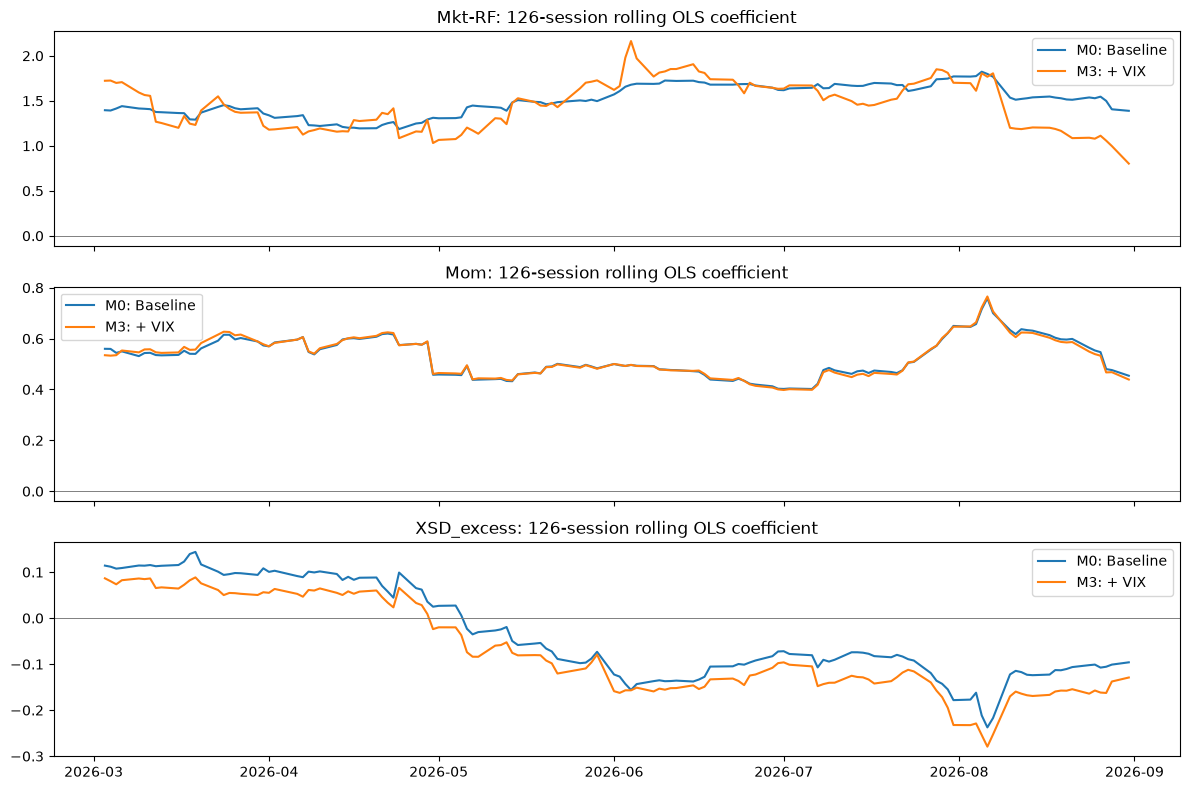

In [28]:
midpoint = len(data)//2
for name in ['Baseline', 'Plus VIX']:
    for half, sample in [('First half', data.iloc[:midpoint]), ('Second half', data.iloc[midpoint:])]:
        record_sensitivity(name+' '+half, sample, MODEL_FACTORS[name])
show_sensitivity([name+' '+half for name in ['Baseline', 'Plus VIX']
                 for half in ['First half', 'Second half']], ['Mkt-RF', 'Mom', 'XSD_excess'])
rolling_rows = []

for name in ['Baseline', 'Plus VIX']:
    for end in range(126, len(data)+1):
        ols, _ = fit_model(data.iloc[end-126:end], MODEL_FACTORS[name])
        rolling_rows.append(dict(model=name, date=data.index[end-1], **ols.params.to_dict()))

rolling_coefficients = pd.DataFrame(rolling_rows)

rolling_coefficients.to_csv(OUTPUT_DIR / 'regression_rolling_coefficients.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, term in zip(axes, ['Mkt-RF', 'Mom', 'XSD_excess']):
    for name in ['Baseline', 'Plus VIX']:
        sub = rolling_coefficients[rolling_coefficients.model == name]
        ax.plot(sub.date, sub[term], label=MODEL_LABELS[name])
    ax.set_title(term + ': 126-session rolling OLS coefficient'); ax.axhline(0, color='gray', lw=.7)
    ax.legend()

fig.tight_layout(); fig.savefig(OUTPUT_DIR / 'regression_rolling_coefficients.png', dpi=160)

plt.show()

**Conclusion.** In M0, the market coefficient is about 1.39 in both halves and Momentum is positive and significant in both. XSD changes sign but is insignificant in both halves. M3's market estimate varies more and has wide intervals, so the checks support cautious exposure interpretation rather than a claim that every coefficient is stable.

**Overall conclusion.** The key result survives the HAC-lag and rate-gap checks: the expanded specifications offer little additional explanatory value, and M0 remains a reasonable primary model. The omission/proxy checks suggest a more compact model or a different industry proxy is worth considering. Sensitivity to the influential dates in Section 14.4 still requires separate leave-one-out regressions.

In [29]:
# Preserve the established export order while displaying checks separately above.
sensitivity_order = ['Baseline omit Mom', 'Baseline omit XSD_excess']
for name in ['Baseline', 'Plus VIX']:
    sensitivity_order.extend([name+' with SOXX', name+' First half', name+' Second half'])
for name in MODEL_NAMES:
    sensitivity_order.extend([name+' excluding rate-affected dates',
                              name+' HAC lag 1', name+' HAC lag 10'])
sensitivity_fit = pd.DataFrame(sensitivity_rows).set_index('specification').loc[sensitivity_order]
sensitivity_coefficients = pd.DataFrame(sensitivity_coefs)
order = {label: i for i, label in enumerate(sensitivity_order)}
sensitivity_coefficients = sensitivity_coefficients.assign(
    _order=sensitivity_coefficients.specification.map(order)).sort_values('_order', kind='stable').drop(columns='_order')
sensitivity_fit.to_csv(OUTPUT_DIR / 'regression_sensitivity_fit.csv')
sensitivity_coefficients.to_csv(OUTPUT_DIR / 'regression_sensitivity_coefficients.csv', index=False)

## 16. Main conclusions

**Final model results.** Each column is a model and each coefficient row is a variable. All four specifications estimate daily NVDA excess return using OLS with an intercept on the same 251 trading observations, from 2025-09-02 to 2026-08-31. The table repeats the reviewed results from Section 12 so the model choice and conclusions can be read together.



In [30]:
# Reuse Section 12 results; export a three-rule table and Beamer-ready fragment.
from _LIB_case1 import export_academic_table
final_table_html = export_academic_table(regression_table, OUTPUT_DIR)
display(HTML(final_table_html))


Variable,M0Baseline,M1+ Yield,M2+ QQQ,M3+ VIX
Alpha (bp/day),3.609(8.201),3.303(8.218),3.319(8.263),2.254(8.405)
Market excess,1.422***(0.205),1.444***(0.216),1.113***(0.426),1.281***(0.478)
SMB,-0.268(0.241),-0.253(0.249),-0.150(0.269),-0.160(0.266)
HML,-0.156(0.227),-0.181(0.236),-0.167(0.238),-0.134(0.241)
RMW,0.480**(0.194),0.480**(0.195),0.524***(0.199),0.526***(0.200)
CMA,-1.297***(0.346),-1.266***(0.357),-1.207***(0.325),-1.209***(0.324)
Momentum,0.448***(0.124),0.452***(0.127),0.440***(0.130),0.440***(0.131)
XSD excess,0.001(0.071),-0.002(0.072),-0.042(0.088),-0.045(0.090)
Yield change (bp / bp),—,1.353(2.540),1.643(2.506),1.862(2.580)
QQQ excess,—,—,0.349(0.376),0.346(0.376)


**Conclusions from the table and the supporting checks in Sections 13–15**

1. **Select M0 among the four primary models.** The baseline explains 58.75% of daily NVDA excess-return variation and has the highest adjusted R-squared (57.56%). Adding factors slightly improves raw fit but does not justify the extra parameters on these sample results.
2. **Interpretation of the main results.** In M0, the following exposures are significant at 5%. Each interpretation holds the other included factors constant:

   - **Market (1.422):** A 1-percentage-point increase in market excess return is associated with a 1.422-percentage-point increase in NVDA excess return, indicating greater-than-one-for-one market sensitivity.
   - **Profitability / RMW (0.480):** When robust-profitability stocks outperform weak-profitability stocks by 1 percentage point, NVDA excess return is associated with an increase of 0.480 percentage points.
   - **Investment / CMA (-1.297):** When conservative-investment stocks outperform aggressive-investment stocks by 1 percentage point, NVDA excess return is associated with a decrease of 1.297 percentage points, indicating exposure toward the aggressive-investment side.
   - **Momentum (0.448):** When past winners outperform past losers by 1 percentage point, NVDA excess return is associated with an increase of 0.448 percentage points.

   These are conditional associations, not causal effects. Alpha, SMB, HML and XSD are not significant at 5% in M0.

3. **Extensions add little.** Yield, QQQ and VIX increase R-squared by only 0.314 percentage points and are jointly insignificant (HAC p = 0.640); M0 retains the highest adjusted R-squared.

4. **Sensitivity checks broadly support M0.** Results are robust to the tested HAC lags and rate-gap exclusions. Momentum contributes to fit; XSD adds little.

5. **Remaining check.** Refit after excluding influential dates one at a time to assess whether they change the conclusions.

### Further work if more time

- **Construct a semiconductor index excluding NVDA.** Build a peer index from listed semiconductor firms to remove NVDA's direct contribution to the industry proxy. Reconstructing the broader factor portfolios without NVDA would be a subsequent extension if the required constituent data are available.
- **Assess exposure stability within the one-year sample.** Extend the existing rolling analysis with confidence intervals and a formal coefficient-stability test to distinguish changes in exposures from estimation noise.
- **Check sensitivity to influential dates.** Refit the models after excluding each high-influence date identified in Section 14.4, one at a time, and compare the coefficients and preferred model with the full-sample results.

### AI usage summary

1. **Model choice.** I proposed an interpretable factor model covering market, industry, interest-rate and Momentum exposures, including the full Fama-French five-factor set. AI helped identify XSD and SOXX as industry proxies and suggested QQQ as an additional technology/growth proxy. The model comparison supported retaining M0 as the preferred primary specification.

2. **Division of work.** I used GPT 6 Astra (Light and Medium) and GPT 6.1 Sol (Medium) through OpenAI Codex. I led the analytical design and data-processing and maintenance approach, directed revisions, and reviewed the results. AI implemented most of the code—approximately 80–85% by my estimate—and provided technical suggestions for diagnostics and sensitivity checks.

3. **Validation methods.** I guided the analysis by asking whether correlations alone were sufficient, how to interpret VIF, and what conclusions the diagnostics supported. AI implemented these checks and supported additional robustness and sensitivity analyses. Numerical checks compared notebook and script results and verified coefficients against an independent least-squares calculation.

4. **Issues encountered.**

   - Long interactions sometimes involved high token usage, slower responses and less consistent answers.
   - Responses were sometimes too verbose; notation and interpretations needed correction.
   - Initial tests missed a VS Code/Conda launch issue; it was fixed and retested using the same launch method.
